In [1]:
import os
# os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID" 
# os.environ["CUDA_VISIBLE_DEVICES"]="3"#gpu_2_1
import re
string = os.popen('nvidia-smi -L').read()
gpus = re.findall('\(([^)]+)', string[string.find("GPU 2"):string.find("GPU 3")])
gpu_2 = gpus[0][6:]
gpu_2_1 = gpus[1][6:]
gpu_2_2 = gpus[2][6:]
os.environ["CUDA_VISIBLE_DEVICES"]=gpu_2_1
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="False"

import jax
import jax.numpy as jnp
import jax.nn as jnn
from jax import grad, vmap, jit, lax
import flax.linen as nn
import optax
from flax.training import train_state
import pandas as pd
import matplotlib.pyplot as plt
from flax.core import unfreeze, freeze
import optax
from soap_jax import soap
from tqdm.auto import trange      # ← 가장 안전
from typing import Callable, Dict, Union, Optional, Any  # 위에 import에 추가
jax.config.update("jax_enable_x64", True)   # (선택) 배정밀도 사용
key = jax.random.PRNGKey(0)

# setting
# 자유롭게 바꿀 수 있는 값들
WIDTH   = 128
DEPTH   = 2
ACT     = 'swish'         # 'tanh', 'relu', 'gelu', 'swish', 'elu', 'sigmoid'…
EPOCHS  = 2000000
N_r, N_b, N_i = 10000, 1000, 500    # Collocation pt, BC pt(regression), IC pt(regression)
N_bpde = 0           # BC pt (BC loss 이용)
N_lab   = 0          # csv 관측점 중 학습에 쓸 개수
LR      = 1.e-3
RESAMPLE_COLL_EVERY = 100

USE_PEXT = True
USE_DYNAMIC_UB = True  # True면 uB = ±sqrt(Te/mi_bar), False면 상수 u_B 사용

# ===== Causal (strict; eq.14–15) 설정 =====
CAUSAL_STRICT   = True        # 논문 causal training ON/OFF
CAUSAL_EPS      = 1.0         # ε in w(t) = exp(-ε * ∫_0^t ∫ |R|^2 dx dτ)
CAUSAL_CLIP_MIN = 1e-6        # 수치 안정성용

In [2]:
import jax.numpy as jnp
#──────────────────────────────────────────────────────────
# 1) CONSTANTS  (SI → 무차원)  — PlasmaPDE에 전달할 config.phys 구성
# ──────────────────────────────────────────────────────────
eps = 1.e-12
# ① SI 입력값
PRS_mTorr = 30.0          # [mTorr]
Prf_W     = 500.0         # [W]
Lp_m      = 0.10          # [m]
Rp_m      = 0.25          # [m]
Ti_SI     = 300.0         # [K]
Tg_SI     = 300.0         # [K]
nN_SI     = 3.22e19 * PRS_mTorr  # [m^-3]

# ② 정규화 기준
n0  = 1.0e16 * 15         # [m^-3] <- 이 부분이 바뀜
T0  = 11604.0             # [K]  (=1 eV / kB)
t0  = 1.0e-8              # [s]
m0  = 1.6605e-27          # [kg] (=1 amu)
kB  = 1.3807e-23          # [J/K]
QE  = 1.6022e-19          # [C]

u0 = jnp.sqrt(kB*T0/m0)   # [m/s]
l0 = u0 * t0              # [m]
k0 = 1.0 / (t0 * n0)      # [m^3 s^-1]
E0 = kB*T0 / (QE*l0)      # [V/m]
R0 = k0 * n0**2           # [m^-3 s^-1]
P0 = n0*kB*T0*(l0**3)/t0  # [W]

# ③ 무차원 값
Lz         = Lp_bar  = Lp_m / l0
Rp_bar  = Rp_m / l0
m_e_bar    = me_bar  = 9.1094e-31 / m0
m_i_bar    = m_beta_bar = mi_bar  = 39.948
T_i_bar    = Ti_bar  = Ti_SI / T0
T_beta_bar = Tg_bar  = Tg_SI / T0
nN_bar  = nN_SI / n0
Prf_bar = Prf_W / P0
dt_bar  = 1.0            # (dt == t0 라서)


# ④ 반응항 상수 (Ṙ = C_R · n̂ · Tê^0.6329 · exp(−α/Tê))
const_Reac = 5.779e-17   # [m^3 s^-1 K^-0.6329]
Eion_K     = 1.864e5     # [K]
C_R        = nN_bar * const_Reac * (T0**0.6329) / k0
alpha      = Eion_K / T0

In [3]:
# ──────────────────────────────────────────────────────────
# 2) PlasmaPDE 구성에 넣을 phys 딕셔너리
# ──────────────────────────────────────────────────────────
phys = dict(
    # 정규화 기준
    n0=float(n0), T0=float(T0), t0=float(t0), m0=float(m0), kB=float(kB), QE=float(QE),

    # 무차원 파라미터
    mi_bar=float(mi_bar), Ti_bar=float(Ti_bar), Tbeta_bar=float(Tg_bar),
    me_bar=float(me_bar), m_beta_bar=float(mi_bar),

    # 기하/전력
    Lp_bar=float(Lp_bar), Rp_bar=float(Rp_bar), Prf_bar=float(Prf_bar),
    PRS_mTorr=float(PRS_mTorr), nN_bar=float(nN_bar),

    # 반응항
    const_Reac=float(const_Reac), Eion_K=float(Eion_K), C_R=float(C_R), alpha=float(alpha),
)

In [4]:
import pandas as pd
import jax
import jax.numpy as jnp

DTYPE = jnp.float32

# === CSV 로더 ===
def load_csv(path="output.csv"):
    df = pd.read_csv(path)
    return (
        jnp.array(df["time[s]"], dtype=DTYPE) / t0,
        jnp.array(df["z[m]"],    dtype=DTYPE) / l0,
        jnp.array(df["ni_norm"], dtype=DTYPE),
        jnp.array(df["Te_norm"], dtype=DTYPE),
        jnp.array(df["E_norm"],  dtype=DTYPE),
        jnp.array(df["Fi_norm"], dtype=DTYPE),
    )

data_path = "/workspace/CODE/ICP/data/output_4_v_new.csv"
t_data, z_data, n_data, Te_data, E_data, G_data = load_csv(data_path)

# 전체 domain의 t, z 범위
t_minmax = jnp.array([jnp.min(t_data).item(), jnp.max(t_data).item()])
z_minmax = jnp.array([jnp.min(z_data).item(), jnp.max(z_data).item()])
Tfinal = t_minmax[1].item()
zfinal = z_minmax[1].item()

N_all = t_data.shape[0]
print("loaded", N_all, "total points")

# === Initial condition 분리 (t = t0 근처) ===
ic_mask   = jnp.isclose(t_data, t_data[0], atol=1e-12)
t_ic_all  = t_data[ic_mask]
z_ic_all  = z_data[ic_mask]
n_ic_all  = n_data[ic_mask]
Te_ic_all = Te_data[ic_mask]
E_ic_all  = E_data[ic_mask]
G_ic_all  = G_data[ic_mask]

# IC를 제외한 나머지를 "일반 시점" 데이터로 사용
t_data = t_data[~ic_mask]
z_data = z_data[~ic_mask]
n_data = n_data[~ic_mask]
Te_data = Te_data[~ic_mask]
E_data = E_data[~ic_mask]
G_data = G_data[~ic_mask]

# t_minmax 는 반드시 전체 기준 (IC 포함)
t_minmax = jnp.array([
    jnp.min(jnp.concatenate([t_ic_all, t_data])).item(),
    jnp.max(jnp.concatenate([t_ic_all, t_data])).item(),
])
zfinal = z_minmax[1]
Tfinal = t_minmax[1]

N_data = t_data.shape[0]
print("loaded", N_data, "non-IC points; IC points:", t_ic_all.shape[0])

# === 1D sampling helpers ===
def _uniform(key, n, low, high):
    u = jax.random.uniform(key, (n,), dtype=DTYPE)
    return low + (high - low) * u

def _left_heavy(key, n, low, high, power: float = 2.0):
    """
    왼쪽(작은 값) 쪽으로 더 치우치게 샘플링 (0^power ~ 1^power)
    """
    u = jax.random.uniform(key, (n,), dtype=DTYPE)
    return low + (high - low) * (u ** power)

def _cheb_symmetric(key, n, low, high):
    """
    Chebyshev 노드 기반(사인/코사인 기반) quasi-uniform 클러스터링
    """
    u = jax.random.uniform(key, (n,), dtype=DTYPE)
    x01 = 0.5 * (1.0 - jnp.cos(jnp.pi * u))
    return low + (high - low) * x01

def _sample_1d(key, n, low, high, mode: str = "uniform", power: float = 2.0):
    """
    mode ∈ {"uniform", "left_heavy", "cheb"}
    """
    if mode == "uniform":
        return _uniform(key, n, low, high)
    elif mode == "left_heavy":
        return _left_heavy(key, n, low, high, power=power)
    elif mode == "cheb":
        return _cheb_symmetric(key, n, low, high)
    else:
        raise ValueError(f"Unknown mode: {mode}")

# ------------------------
# main sampler (업그레이드)
# ------------------------
def sample_training_points(
    key,
    N_r,   # collocation (PDE residual) 포인트 수
    N_b,   # boundary 포인트 수 (좌+우)
    N_i,   # IC 포인트 수
    *,
    # (1) 체비셰프 on/off 스위치 + 랜덤 모드 선택
    use_chebyshev: bool = False,          # True면 기본 샘플러가 cheb
    random_mode: str = "uniform",         # "uniform" or "left_heavy"
    t_power: float = 5.0,
    z_power: float = 2.0,

    # (2) 경계 데이터 사용 on/off
    use_boundary_data: bool = False,      # True면 CSV 경계 데이터를 라벨로 사용

    # (3) 경계 데이터 판정 허용 오차
    boundary_tol: float = 1e-12,

    # (4) collocation을 외부에서 고정 입력으로 넘길 수 있게
    t_r_fixed=None,
    z_r_fixed=None,
):
    """
    반환:
      (t_r, z_r,
       t_b0, z_b0, t_b1, z_b1,
       t_i, z_i, n_i_ic, Te_i_ic, E_i_ic, G_i_ic,
       n_b0_lab, Te_b0_lab, E_b0_lab, G_b0_lab,
       n_b1_lab, Te_b1_lab, E_b1_lab, G_b1_lab)
    """
    # 샘플 모드 결정
    mode_t_r  = "cheb" if use_chebyshev else random_mode
    mode_z_r  = "cheb" if use_chebyshev else random_mode
    mode_t_b0 = "cheb" if use_chebyshev else random_mode
    mode_t_b1 = "cheb" if use_chebyshev else random_mode

    # 좌/우 경계 포인트 수 분할
    N_b0 = N_b // 2
    N_b1 = N_b - N_b0

    # RNG 키 분할
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)

    # 1) collocation (r) — 외부에서 고정 포인트가 있으면 그대로 사용
    if (t_r_fixed is not None) and (z_r_fixed is not None):
        t_r = jnp.asarray(t_r_fixed, dtype=DTYPE).reshape(-1)
        z_r = jnp.asarray(z_r_fixed, dtype=DTYPE).reshape(-1)
        assert t_r.shape[0] == N_r and z_r.shape[0] == N_r, \
            f"fixed collocation length must be N_r={N_r}"
    else:
        t_r = _sample_1d(k1, N_r, t_minmax[0], t_minmax[1], mode=mode_t_r, power=t_power)
        z_r = _sample_1d(k2, N_r, z_minmax[0], z_minmax[1],  mode=mode_z_r, power=z_power)

    # 2) boundary (좌/우): 데이터 기반 또는 단순 위치 샘플링
    if use_boundary_data:
        # z = 0
        b0_mask = jnp.isclose(z_data, 0.0, atol=boundary_tol)
        t_b0_all  = t_data[b0_mask]
        z_b0_all  = z_data[b0_mask]
        n_b0_all  = n_data[b0_mask]
        Te_b0_all = Te_data[b0_mask]
        E_b0_all  = E_data[b0_mask]
        G_b0_all  = G_data[b0_mask]
        N_b0_tot  = int(t_b0_all.shape[0])
        if N_b0_tot == 0:
            raise ValueError("No boundary data found at z=0 within tolerance. Consider increasing boundary_tol.")
        idx_b0 = jax.random.choice(k3, N_b0_tot, shape=(N_b0,), replace=(N_b0 > N_b0_tot))
        t_b0   = t_b0_all[idx_b0]
        z_b0   = z_b0_all[idx_b0]
        n_b0_lab  = n_b0_all[idx_b0]
        Te_b0_lab = Te_b0_all[idx_b0]
        E_b0_lab  = E_b0_all[idx_b0]
        G_b0_lab  = G_b0_all[idx_b0]

        # z = zfinal
        b1_mask = jnp.isclose(z_data, zfinal, atol=boundary_tol)
        t_b1_all  = t_data[b1_mask]
        z_b1_all  = z_data[b1_mask]
        n_b1_all  = n_data[b1_mask]
        Te_b1_all = Te_data[b1_mask]
        E_b1_all  = E_data[b1_mask]
        G_b1_all  = G_data[b1_mask]
        N_b1_tot  = int(t_b1_all.shape[0])
        if N_b1_tot == 0:
            raise ValueError("No boundary data found at z=zfinal within tolerance. Consider increasing boundary_tol.")
        idx_b1 = jax.random.choice(k4, N_b1_tot, shape=(N_b1,), replace=(N_b1 > N_b1_tot))
        t_b1   = t_b1_all[idx_b1]
        z_b1   = z_b1_all[idx_b1]
        n_b1_lab  = n_b1_all[idx_b1]
        Te_b1_lab = Te_b1_all[idx_b1]
        E_b1_lab  = E_b1_all[idx_b1]
        G_b1_lab  = G_b1_all[idx_b1]
    else:
        # 경계에서 시간만 샘플, z는 고정
        t_b0 = _sample_1d(k3, N_b0, t_minmax[0], Tfinal, mode=mode_t_b0, power=t_power)
        z_b0 = jnp.zeros((N_b0,), dtype=DTYPE)

        t_b1 = _sample_1d(k4, N_b1, t_minmax[0], Tfinal, mode=mode_t_b1, power=t_power)
        z_b1 = jnp.full((N_b1,), zfinal, dtype=DTYPE)

        # 라벨 없음 (빈 배열)
        n_b0_lab  = jnp.zeros((0,), dtype=DTYPE)
        Te_b0_lab = jnp.zeros((0,), dtype=DTYPE)
        E_b0_lab  = jnp.zeros((0,), dtype=DTYPE)
        G_b0_lab  = jnp.zeros((0,), dtype=DTYPE)

        n_b1_lab  = jnp.zeros((0,), dtype=DTYPE)
        Te_b1_lab = jnp.zeros((0,), dtype=DTYPE)
        E_b1_lab  = jnp.zeros((0,), dtype=DTYPE)
        G_b1_lab  = jnp.zeros((0,), dtype=DTYPE)

    # 3) Initial condition (t=0) 라벨 샘플링
    N_ic_tot = int(t_ic_all.shape[0])
    replace_ic = N_i > N_ic_tot
    idx_ic = jax.random.choice(k5, N_ic_tot, shape=(N_i,), replace=replace_ic)

    t_i     = t_ic_all[idx_ic]
    z_i     = z_ic_all[idx_ic]
    n_i_ic  = n_ic_all[idx_ic]
    Te_i_ic = Te_ic_all[idx_ic]
    E_i_ic  = E_ic_all[idx_ic]
    G_i_ic  = G_ic_all[idx_ic]

    # 최종 반환 (Data regression / N_bpde 완전히 제거된 구조)
    return (
        t_r, z_r,
        t_b0, z_b0, t_b1, z_b1,
        t_i, z_i, n_i_ic, Te_i_ic, E_i_ic, G_i_ic,
        n_b0_lab, Te_b0_lab, E_b0_lab, G_b0_lab,
        n_b1_lab, Te_b1_lab, E_b1_lab, G_b1_lab,
    )


loaded 25551 total points
loaded 25500 non-IC points; IC points: 51


In [5]:
(key,) = jax.random.split(key, 1)
batch_test = sample_training_points(
    key,
    N_r=N_r,
    N_b=N_b,
    N_i=N_i,
    use_boundary_data=True,
)

(t_r, z_r, t_b0, z_b0, t_b1, z_b1, t_i, z_i, n_i_ic, Te_i_ic, E_i_ic, G_i_ic, n_b0_lab, Te_b0_lab, E_b0_lab, G_b0_lab, n_b1_lab, Te_b1_lab, E_b1_lab, G_b1_lab,) = batch_test


In [6]:

# ──────────────────────────────────────────────────────────
# 2) Pirate Network (Flax) — apply(x) → (features, y_raw[4])
# ──────────────────────────────────────────────────────────
import jax
import jax.numpy as jnp
from jax import random
from flax import linen as nn
from flax.linen.initializers import glorot_normal, zeros
from typing import Callable, Dict, Union

DTYPE = jnp.float64  # 네 코드와 맞춤
# Random Weight Factorization
def _weight_fact(init_fn: Callable, mean: float, stddev: float):
    """jaxpi 스타일 RWF: kernel 파라미터를 (g, v)로 등록
       - w ~ init_fn(key1, shape)  (기본 커널)
       - g ~ exp(N(mean, stddev))  (출력 채널별 스케일; shape[-1])
       - v = w / g                 (가중치 재파라미터화)
       반환: (g, v)
    """
    def init(key, shape):
        key1, key2 = random.split(key)
        w = init_fn(key1, shape)                              # (in, out)
        g = mean + jax.nn.initializers.normal(stddev)(key2,   # (out,)
                                                   (shape[-1],))
        g = jnp.exp(g).astype(w.dtype)
        v = (w / g).astype(w.dtype)                           # (in, out) / (out,)
        return g, v
    return init

class Dense(nn.Module):
    features: int
    kernel_init: Callable = glorot_normal()
    bias_init: Callable = zeros
    reparam: Union[None, Dict] = None
    dtype: any = DTYPE
    param_dtype: any = DTYPE

    @nn.compact
    def __call__(self, x):
        in_dim = x.shape[-1]
        out_dim = self.features

        if self.reparam is None:
            kernel = self.param(
                "kernel", self.kernel_init, (in_dim, out_dim)
            ).astype(self.dtype)

        elif self.reparam["type"] == "weight_fact":
            g, v = self.param(
                "kernel",
                _weight_fact(
                    self.kernel_init,
                    mean=self.reparam.get("mean", 1.0),
                    stddev=self.reparam.get("stddev", 0.1),
                ),
                (in_dim, out_dim),
            )
            # kernel = g * v  (브로드캐스팅: (out,) * (in,out))
            kernel = (g * v).astype(self.dtype)

        else:
            raise ValueError(f"Unknown reparam type: {self.reparam}")

        bias = self.param("bias", self.bias_init, (out_dim,)).astype(self.dtype)

        # matmul
        y = jnp.dot(x.astype(self.dtype), kernel) + bias
        return y

ACTS = {
    'tanh': jnn.tanh, 'relu': jnn.relu, 'gelu': jnn.gelu,
    'swish': jnn.swish, 'elu': jnn.elu, 'sigmoid': jnn.sigmoid, 'sin': jnp.sin
}

class PirateBlock(nn.Module):
    width: int
    act: str
    reparam: Union[None, Dict] = None  # ← RWF 설정을 그대로 받음

    @nn.compact
    def __call__(self, x, U, V):
        f = ACTS[self.act]
        h1 = f(Dense(self.width, dtype=DTYPE, param_dtype=DTYPE, reparam=self.reparam)(x))
        z1 = h1 * U + (1.0 - h1) * V
        h2 = f(Dense(self.width, dtype=DTYPE, param_dtype=DTYPE, reparam=self.reparam)(z1))
        z2 = h2 * U + (1.0 - h2) * V
        h  = f(Dense(self.width, dtype=DTYPE, param_dtype=DTYPE, reparam=self.reparam)(z2))
        alpha = self.param('alpha', nn.initializers.zeros, (), DTYPE)
        return alpha * h + (1.0 - alpha) * x

class PiratePINN_Network(nn.Module):
    width: int
    n_block: int
    act: str = 'tanh'
    # RFF
    fft: bool = False
    B: int = 64
    freq: float = 1.0
    # 좌표 정규화
    coord_norm: bool = False
    t_minmax: Optional[jnp.ndarray] = None   
    z_minmax: Optional[jnp.ndarray] = None   
    # RWF 설정
    reparam: Optional[Dict[str, Any]] = None  

    def setup(self):
        #FFT, U, V에 대해서는 공동 사용
        if self.fft:
            self.B_mat = self.param(
                'B_mat',
                jax.nn.initializers.normal(stddev=jnp.sqrt(2.0)),
                (self.B, 2), DTYPE
            )
        self.gate_U = Dense(self.width, dtype=DTYPE, param_dtype=DTYPE, reparam=self.reparam)
        self.gate_V = Dense(self.width, dtype=DTYPE, param_dtype=DTYPE, reparam=self.reparam)
        # 나머지에 대해서는 따로
        def make_blocks():
            return [PirateBlock(self.width, self.act, reparam=self.reparam)
                    for _ in range(self.n_block)]
        self.blocks_ni = make_blocks()
        self.blocks_Te = make_blocks()
        self.blocks_E  = make_blocks()
        self.blocks_G  = make_blocks()

        self.out_ni = Dense(1, dtype=DTYPE, param_dtype=DTYPE, reparam=None)
        self.out_Te = Dense(1, dtype=DTYPE, param_dtype=DTYPE, reparam=None)
        self.out_E  = Dense(1, dtype=DTYPE, param_dtype=DTYPE, reparam=None)
        self.out_G  = Dense(1, dtype=DTYPE, param_dtype=DTYPE, reparam=None)

    def _normalize(self, x):
        if (self.t_minmax is None) or (self.z_minmax is None):
            return x
        t, z  = x[..., 0], x[..., 1]
        t0,t1 = self.t_minmax
        z0,z1 = self.z_minmax
        t_ = (t - t0)/(t1 - t0 + 1e-12)
        z_ = (z - z0)/(z1 - z0 + 1e-12)
        return jnp.stack([t_, z_], axis=-1)

    def _fourier_embed(self, x):
        proj = 2*jnp.pi*self.freq*(x @ self.B_mat.T)  # (N,B)
        return jnp.concatenate([jnp.sin(proj), jnp.cos(proj)], axis=-1)

    def __call__(self, x):
        x  = self._normalize(x) if self.coord_norm else x
        Φ  = self._fourier_embed(x) if self.fft else x
        f = ACTS[self.act]
        U = f(self.gate_U(Φ))
        V = f(self.gate_V(Φ))
        def run_head(blocks):
            h = Φ
            for blk in blocks:
                h = blk(h, U, V)
            return h
        h_ni = run_head(self.blocks_ni)
        h_Te = run_head(self.blocks_Te)
        h_E  = run_head(self.blocks_E)
        h_G  = run_head(self.blocks_G)
        y_ni = self.out_ni(h_ni)  # (...,1)
        y_Te = self.out_Te(h_Te)  # (...,1)
        y_E  = self.out_E(h_E)    # (...,1)
        y_G  = self.out_G(h_G)    # (...,1)

        y4 = jnp.concatenate([y_ni, y_Te, y_E, y_G], axis=-1)  # (...,4)
        feats = {'ni': h_ni, 'Te': h_Te, 'E': h_E, 'G': h_G}   # 진단/시각화용
        return feats, y4

In [7]:
from dataclasses import dataclass

@dataclass
class NetCfg:
    use_rwf: bool = False      # ← 여기만 False면 RWF 완전 OFF
    rwf_mean: float = 1.0
    rwf_std: float  = 0.1

def reparam_from_cfg(cfg: NetCfg):
    return {"type": "weight_fact", "mean": cfg.rwf_mean, "stddev": cfg.rwf_std} if cfg.use_rwf else None

cfg = NetCfg(use_rwf=True)  # ← RWF On

model = PiratePINN_Network(
    width=WIDTH, n_block=DEPTH, act=ACT,
    fft=True, B=WIDTH//2, freq=1.0,                 # RFF with N(0,2) inside
    coord_norm=True, t_minmax=t_minmax, z_minmax=z_minmax,
    reparam=reparam_from_cfg(cfg)                      # ← 여기!
)

def _vars_for_apply(params):
    # params가 {'nn': variables} 이면 variables만 꺼내고,
    # 이미 variables(dict with 'params' collection)면 그대로 사용
    return params['nn'] if (isinstance(params, dict) and 'nn' in params) else params

def model_apply(params, t, z):
    variables = _vars_for_apply(params)  # ★ 여기서 정규화
    inputs = jnp.stack([t, z], axis=-1).astype(DTYPE)
    _, y_raw = model.apply(variables, inputs)
    Ni_raw = y_raw[..., 0].astype(DTYPE)
    Te_raw = y_raw[..., 1].astype(DTYPE)
    E_raw  = y_raw[..., 2].astype(DTYPE)
    Gi_raw = y_raw[..., 3].astype(DTYPE)
    Te_hat = jnp.exp(Te_raw)
    return Ni_raw, Te_hat, E_raw, Gi_raw

# ion-neutral collision (무차원 상수) — model.py와 동일식
def compute_nu_i_bar_const():
    mi_SI = m_i_bar * m0
    Ti_SI = T_i_bar * T0
    k0_SI = 1.0/(t0*n0)
    return nN_bar * (50e-20 * jnp.sqrt(8.0*kB*Ti_SI/(jnp.pi*mi_SI))) / k0_SI

nu_i_bar_const = compute_nu_i_bar_const()  # 상수

# electron-neutral collision (무차원, Te-의존)
def nu_eb_bar_fn(Te_hat):
    # Te_hat: 무차원(K/T0)
    Te_SI = Te_hat * T0
    k0_SI = 1.0/(t0*n0)
    return nN_bar * (3.5665e-15 * (Te_SI**0.3785) * jnp.exp(-2.292e4/(Te_SI + 1e-30))) / k0_SI

# 반응항 (무차원)  Ṙ = C_R · n̂ · Tê^0.6329 · exp(−α/Tê)
# C_R, alpha는 네가 constants에서 이미 정의했다고 가정
def R_tilde(n_hat, Te_hat):
    return C_R * n_hat * (Te_hat**0.6329) * jnp.exp(-alpha/(Te_hat + 1e-30))

Z_GRID = jnp.linspace(0.0, Lz, 10, dtype=DTYPE)

def Pext_bar_fn(params, t, z, z_all=None):
    if z_all is None:
        z_all = Z_GRID
    def n_at(zz):
        N_hat, _, _, _ = model_apply(params, t, zz)
        return jnp.exp(N_hat)
    n_line = vmap(n_at)(z_all)
    ave_ni = lax.stop_gradient(jnp.mean(n_line))

    ME, EPS0, CV = 9.1094e-31, 8.8542e-12, 2.9979e8
    omega_p = jnp.sqrt(ave_ni*n0 * (QE**2)/(ME*EPS0))
    delta_m = CV/(omega_p + 1e-30)

    u0_loc = jnp.sqrt(kB*T0/m0); l0_loc = u0_loc * t0
    delta_n = delta_m / (l0_loc + 1e-30)

    num = 2.0 * Prf_bar * jnp.exp(-2.0*z/(delta_n + 1e-30))
    den = (delta_n + 1e-30) * (1.0 - jnp.exp(-2.0*Lz/(delta_n + 1e-30))) * (jnp.pi * Rp_bar * Rp_bar)
    return (num / den).astype(DTYPE)

def gamma_tilde(params, t, z):
    N_hat, Te_hat, E_hat, G_hat = model_apply(params, t, z)
    n_hat = jnp.exp(N_hat)
    return G_hat, E_hat, N_hat, Te_hat, n_hat

# 벡터화
v_gamma_tilde = vmap(gamma_tilde, in_axes=(None, 0, 0))

def residuals(params, t, z):
    G_hat, E_hat, N_hat, Te_hat, n_hat = gamma_tilde(params, t, z)

    # r1: n dN/dt + dΓ/dz - R = 0
    dN_dt = grad(lambda tt: model_apply(params, tt, z)[0])(t)
    dG_dz = grad(lambda zz: gamma_tilde(params, t, zz)[0])(z)
    R_hat = R_tilde(n_hat, Te_hat)
    r_1   = n_hat * dN_dt + dG_dz - R_hat

    # r2: Γ - μ_i n (E - T_i dN/dz) = 0
    mu_i   = 1.0 / (m_i_bar * (nu_i_bar_const + eps))
    dN_dz  = grad(lambda zz: model_apply(params, t, zz)[0])(z)
    r_2   = G_hat - n_hat * mu_i * (E_hat - T_i_bar * dN_dz)

    # r3 : E + (Te dN/dz + dTe/dz) = 0
    dTe_dz = grad(lambda zz: model_apply(params, t, zz)[1])(z)
    r_3 = E_hat + (Te_hat * dN_dz + dTe_dz)

    # r4: ∂t(1.5 nTe) + ∂z(2.5 ΓTe) - ∂z( κ ∂zTe ) - [Pext - EΓ - 3(me/mb) n ν_eN(Te)(Te - Tβ) - Ei] = 0
    #   κ = (5/2) (n Te) / (m_e_bar ν_eN(Te))
    def kappa_at(Te_, n_):
        return 2.5 * (n_*Te_) / (m_e_bar * (nu_eb_bar_fn(Te_) + eps))

    # ∂t(1.5 nTe)
    def nTe_time(tt):
        N_, Te_, _, _= model_apply(params, tt, z)
        return 1.5 * jnp.exp(N_) * Te_
    d_nTe_dt = grad(nTe_time)(t)

    # ∂z(2.5 ΓTe)
    def GTe_space(zz):
        G_, _, _, Te_, _ = gamma_tilde(params, t, zz)
        return 2.5 * G_ * Te_
    d_GTe_dz = grad(GTe_space)(z)

    # -∂z( κ ∂zTe )
    dTe_dz = grad(lambda zz: model_apply(params, t, zz)[1])(z)
    kappa  = kappa_at(Te_hat, n_hat)
    d_q_dz = grad(lambda zz: kappa_at(model_apply(params, t, zz)[1],
                                      jnp.exp(model_apply(params, t, zz)[0]))
                           * grad(lambda zzz: model_apply(params, t, zzz)[1])(zz)
                  )(z)

    # RHS terms
    Pext = Pext_bar_fn(params, t, z)
    nu_eN = nu_eb_bar_fn(Te_hat)
    Ei    = 15.6 * R_hat
    energy_rhs = Pext - (E_hat*G_hat) - 3.0*(m_e_bar/m_beta_bar)*n_hat*nu_eN*(Te_hat - T_beta_bar) - Ei

    r_4 = d_nTe_dt + d_GTe_dz - d_q_dz - energy_rhs
    return r_1, r_2, r_3, r_4

v_residuals = vmap(residuals, in_axes=(None, 0, 0))

In [8]:
def _sort_by_time(t, *arrays):
    idx = jnp.argsort(t.reshape(-1))
    return (t.reshape(-1)[idx],) + tuple(a.reshape(-1)[idx] for a in arrays)

def _causal_temporal_weights_strict(residual_sq_series, eps):
    N      = residual_sq_series.shape[0]
    csum   = jnp.cumsum(residual_sq_series)                         # [r1, r1+r2, ...]
    past   = jnp.concatenate([jnp.array([0.0], DTYPE), csum[:-1]])  # sum_{k<i} r_k
    denom  = jnp.arange(N, dtype=DTYPE)
    denom  = jnp.maximum(denom, 1.0)                                # i=1 보호
    pm     = past / denom                                           # mean_{k<i}
    w      = jnp.exp(-jnp.asarray(eps, DTYPE) * pm)
    w      = jnp.clip(w, CAUSAL_CLIP_MIN, 1e6)
    return lax.stop_gradient(w)  # 논문 권고: w는 stop-gradient

def _ensure_pairwise_1d(t, z):
    t = jnp.atleast_1d(t)
    z = jnp.atleast_1d(z)
    if t.size == z.size:
        return t.reshape(-1), z.reshape(-1)
    # 서로 길이가 다르면 카테시안 곱으로 모든 조합 평가
    T, Z = jnp.meshgrid(t.reshape(-1), z.reshape(-1), indexing='ij')
    return T.reshape(-1), Z.reshape(-1)

In [9]:
from flax import struct
import jax
import jax.numpy as jnp
from flax.training import train_state as flax_train_state

DTYPE = jnp.float64

@struct.dataclass
class SAWConfig:
    update_every: int = 1000  # 매 1000 step마다 λ 업데이트
    ema_beta: float = 0.9
    eps: float = 1e-12
    normalize: bool = True    # 평균 1 정규화 여부

def _default_saw():
    # r1, r2, r3, r4, bc, ic 에 대해 각각 λ와 EMA grad norm 저장
    return {
        'lambda_r1': jnp.array(1.0, DTYPE),
        'lambda_r2': jnp.array(1.0, DTYPE),
        'lambda_r3': jnp.array(1.0, DTYPE),
        'lambda_r4': jnp.array(1.0, DTYPE),
        'lambda_bc': jnp.array(1.0, DTYPE),
        'lambda_ic': jnp.array(1.0, DTYPE),

        'g_r1_ema':  jnp.array(1.0, DTYPE),
        'g_r2_ema':  jnp.array(1.0, DTYPE),
        'g_r3_ema':  jnp.array(1.0, DTYPE),
        'g_r4_ema':  jnp.array(1.0, DTYPE),
        'g_bc_ema':  jnp.array(1.0, DTYPE),
        'g_ic_ema':  jnp.array(1.0, DTYPE),
    }

class TrainState(flax_train_state.TrainState):
    saw: dict = struct.field(pytree_node=True,  default_factory=_default_saw)
    saw_cfg: SAWConfig = struct.field(pytree_node=False, default_factory=SAWConfig)

def _l2_norm_pytree(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    return jnp.sqrt(sum([jnp.sum(jnp.square(x)) for x in leaves]))

def _grad_norm_of_term(params, batch, term):
    def term_loss(p):
        # Lp_total, Lb_total, Li_total, Ld_total, extras
        Lp, Lb, Li, extras = compute_losses_unweighted(p, batch)
        if term == 'r1':
            return extras['phys_r1']
        elif term == 'r2':
            return extras['phys_r2']
        elif term == 'r3':
            return extras['phys_r3']
        elif term == 'r4':
            return extras['phys_r4']
        elif term == 'bc':
            return Lb
        elif term == 'ic':
            return Li
        else:
            raise ValueError(f"Unknown term for grad-norm: {term}")

    g = jax.grad(term_loss)(params)
    return _l2_norm_pytree(g)

def _update_saw(state, params, batch):
    cfg = state.saw_cfg
    beta, eps = jnp.array(cfg.ema_beta, DTYPE), jnp.array(cfg.eps, DTYPE)
    s = state.saw

    # 1) 현재 step에서 각 항목별 grad-norm
    g_r1  = _grad_norm_of_term(params, batch, 'r1')
    g_r2  = _grad_norm_of_term(params, batch, 'r2')
    g_r3  = _grad_norm_of_term(params, batch, 'r3')
    g_r4  = _grad_norm_of_term(params, batch, 'r4')
    g_bc  = _grad_norm_of_term(params, batch, 'bc')
    g_ic  = _grad_norm_of_term(params, batch, 'ic')

    # 2) EMA 업데이트
    g_r1_ema  = beta * s['g_r1_ema']  + (1.0 - beta) * g_r1
    g_r2_ema  = beta * s['g_r2_ema']  + (1.0 - beta) * g_r2
    g_r3_ema  = beta * s['g_r3_ema']  + (1.0 - beta) * g_r3
    g_r4_ema  = beta * s['g_r4_ema']  + (1.0 - beta) * g_r4
    g_bc_ema  = beta * s['g_bc_ema']  + (1.0 - beta) * g_bc
    g_ic_ema  = beta * s['g_ic_ema']  + (1.0 - beta) * g_ic

    # 3) GradNorm 방식 λ 업데이트
    sum_g = g_r1_ema + g_r2_ema + g_r3_ema + g_r4_ema + g_bc_ema + g_ic_ema
    sum_g = sum_g + eps

    lam_r1 = sum_g / (g_r1_ema + eps)
    lam_r2 = sum_g / (g_r2_ema + eps)
    lam_r3 = sum_g / (g_r3_ema + eps)
    lam_r4 = sum_g / (g_r4_ema + eps)
    lam_bc = sum_g / (g_bc_ema + eps)
    lam_ic = sum_g / (g_ic_ema + eps)

    # 4) 평균 1로 정규화 (항목 수 = 6)
    if cfg.normalize:
        n_terms = 6
        denom = (lam_r1 + lam_r2 + lam_r3 + lam_r4 + lam_bc + lam_ic) / n_terms
        lam_r1 = lam_r1 / denom
        lam_r2 = lam_r2 / denom
        lam_r3 = lam_r3 / denom
        lam_r4 = lam_r4 / denom
        lam_bc = lam_bc / denom
        lam_ic = lam_ic / denom

    new_saw = {
        'lambda_r1': lam_r1, 'lambda_r2': lam_r2,
        'lambda_r3': lam_r3, 'lambda_r4': lam_r4,
        'lambda_bc': lam_bc, 'lambda_ic': lam_ic,

        'g_r1_ema': g_r1_ema, 'g_r2_ema': g_r2_ema,
        'g_r3_ema': g_r3_ema, 'g_r4_ema': g_r4_ema,
        'g_bc_ema': g_bc_ema, 'g_ic_ema': g_ic_ema,
    }
    return state.replace(saw=new_saw)


# 손실 항목별(phys/bc/ic/data)로 분해해서 반환 — loss_fn의 “항목 계산” 부분만 떼서 사용
def compute_losses_unweighted(params, batch, causal_state=None):
    pnn = params['nn'] if (isinstance(params, dict) and 'nn' in params) else params

    def _safe_mean(x):
        return 0.0 if (x.size == 0) else jnp.mean(x)

    (t_r, z_r,
     t_b0, z_b0, t_b1, z_b1,
     t_i, z_i, n_i_ic, Te_i_ic, E_i_ic, G_i_ic,
     n_b0_lab, Te_b0_lab, E_b0_lab, G_b0_lab,
     n_b1_lab, Te_b1_lab, E_b1_lab, G_b1_lab) = batch

    # ---------------- Physics = PDE ----------------
    if CAUSAL_STRICT:
        t_r1, z_r1 = _sort_by_time(t_r, z_r)
        r1, r2, r3, r4 = v_residuals(pnn, t_r1, z_r1)

        R2_series = r1**2 + r2**2 + r3**2 + r4**2
        w = _causal_temporal_weights_strict(R2_series, CAUSAL_EPS)
        wsum = jnp.sum(w) + 1e-12

        L_phys_r1 = jnp.sum(w * (r1**2)) / wsum
        L_phys_r2 = jnp.sum(w * (r2**2)) / wsum
        L_phys_r3 = jnp.sum(w * (r3**2)) / wsum
        L_phys_r4 = jnp.sum(w * (r4**2)) / wsum
    else:
        t_r1, z_r1 = _ensure_pairwise_1d(t_r, z_r)
        r1, r2, r4, r3 = v_residuals(pnn, t_r1, z_r1)  # 호출 순서는 기존 정의에 맞게
        L_phys_r1 = jnp.mean(r1**2)
        L_phys_r2 = jnp.mean(r2**2)
        L_phys_r3 = jnp.mean(r3**2)
        L_phys_r4 = jnp.mean(r4**2)

    L_phys_total = L_phys_r1 + L_phys_r2 + L_phys_r3 + L_phys_r4
    # ---------------- /Physics ----------------

    # ---------------- Boundary (label-based only) ---------------

    L_bc_G_L = 0.0; L_bc_G_R = 0.0
    L_bc_E_L = 0.0; L_bc_E_R = 0.0
    L_bc_Te_L = 0.0; L_bc_Te_R = 0.0
    L_bc_n_L  = 0.0; L_bc_n_R  = 0.0

    # 왼 경계 (z=0)
    t_b0_, z_b0_ = _ensure_pairwise_1d(t_b0, z_b0)
    G_b0_pred, E_b0_pred, _, Te_b0_pred, n_b0_pred = v_gamma_tilde(pnn, t_b0_, z_b0_)
    L_bc_G_L  = jnp.mean((G_b0_pred - G_b0_lab.reshape(-1))**2)
    L_bc_E_L  = jnp.mean((E_b0_pred - E_b0_lab.reshape(-1))**2)
    L_bc_n_L  = jnp.mean((n_b0_pred - n_b0_lab.reshape(-1))**2)
    L_bc_Te_L = jnp.mean((Te_b0_pred - Te_b0_lab.reshape(-1))**2)

    # 오른 경계 (z=zfinal)
    t_b1_, z_b1_ = _ensure_pairwise_1d(t_b1, z_b1)
    G_b1_pred, E_b1_pred, _, Te_b1_pred, n_b1_pred = v_gamma_tilde(pnn, t_b1_, z_b1_)
    L_bc_G_R  = jnp.mean((G_b1_pred - G_b1_lab.reshape(-1))**2)
    L_bc_E_R  = jnp.mean((E_b1_pred - E_b1_lab.reshape(-1))**2)
    L_bc_n_R  = jnp.mean((n_b1_pred - n_b1_lab.reshape(-1))**2)
    L_bc_Te_R = jnp.mean((Te_b1_pred - Te_b1_lab.reshape(-1))**2)

    # PDE형 경계(bc_flux, dTe/dz)는 제거
    L_bc_reg_total = (
        L_bc_G_L + L_bc_G_R +
        L_bc_E_L + L_bc_E_R +
        L_bc_n_L + L_bc_n_R +
        L_bc_Te_L + L_bc_Te_R
    )
    L_bc_total = L_bc_reg_total
    # ---------------- /Boundary ----------------

    # ---------------- Initial Condition ----------------
    t_i1, z_i1 = _ensure_pairwise_1d(t_i, z_i)
    N_i0, Te_i0, _, _ = jax.vmap(lambda tt, zz: model_apply(pnn, tt, zz))(t_i1, z_i1)

    n_ic_target  = n_i_ic.reshape(-1)
    Te_ic_target = Te_i_ic.reshape(-1)

    # 주의: N_i0 (log n) vs n_ic_target (linear n) 비교는 의도대로라면 OK,
    #       아니라면 log 변환 필요.
    L_ic_N  = jnp.mean((jnp.exp(N_i0) - n_ic_target)**2)
    L_ic_Te = jnp.mean((Te_i0 - Te_ic_target)**2)
    L_ic_total = L_ic_N + L_ic_Te
    # ---------------- /IC ----------------

    extras = {
        'total': L_phys_total + L_bc_total + L_ic_total,
        'phys_r1': L_phys_r1, 'phys_r2': L_phys_r2,
        'phys_r3': L_phys_r3, 'phys_r4': L_phys_r4,

        'bc_total': L_bc_total,
        'bc_G_L': L_bc_G_L, 'bc_G_R': L_bc_G_R,
        'bc_E_L': L_bc_E_L, 'bc_E_R': L_bc_E_R,
        'bc_n_L': L_bc_n_L, 'bc_n_R': L_bc_n_R,
        'bc_Te_L': L_bc_Te_L, 'bc_Te_R': L_bc_Te_R,

        'ic_total': L_ic_total,
        'ic_N': L_ic_N, 'ic_Te': L_ic_Te,
    }

    return L_phys_total, L_bc_total, L_ic_total, extras


In [10]:
def create_train_state(key, lr=LR, b1=0.9, b2=0.999, weight_decay=0.0,
                       precondition_frequency=2, clip_norm=1.0,
                       use_decay=True, decay_steps=2000, decay_rate=0.9, staircase=False):
    net_vars = model.init(key, jnp.ones((1,2), dtype=DTYPE))

    if use_decay:
        # Paris 논문 세팅팅
        lr_or_schedule = optax.warmup_exponential_decay_schedule(
            init_value=jnp.array(0.0, dtype=DTYPE),
            peak_value=jnp.array(1e-3, dtype=DTYPE),
            warmup_steps=22_000,
            transition_steps=2_000,
            decay_rate=0.9,
            staircase=True
        )
    else:
        lr_or_schedule = jnp.array(lr, dtype=DTYPE)

    tx = optax.chain(
        optax.clip_by_global_norm(clip_norm),
        soap(
            learning_rate=lr_or_schedule,
            b1=b1, b2=b2,
            weight_decay=weight_decay,
            precondition_frequency=precondition_frequency,
        )
    )

    return TrainState.create(
        apply_fn=None,
        params={'nn': net_vars},
        tx=tx,
        saw=_default_saw(),
        saw_cfg=SAWConfig(),
    )



In [11]:
# Parameter 해시 유틸 (RWF 대응 버전)
import hashlib, numpy as np
import jax.numpy as jnp
from flax.traverse_util import flatten_dict

def _hash_leaf(h, key, v):
    """leaf v를 타입별로 안전하게 해시"""
    # JAX/NumPy 배열
    if isinstance(v, (jnp.ndarray, np.ndarray)):
        arr = np.asarray(v)
        # dtype/shape까지 포함시켜 충돌 감소
        h.update(str(arr.dtype).encode())
        h.update(np.asarray(arr.shape, dtype=np.int64).tobytes())
        h.update(arr.tobytes())
        return

    # 튜플/리스트: 각 원소를 재귀적으로 해시
    if isinstance(v, (tuple, list)):
        h.update(f"{key}#len={len(v)}".encode())
        for i, item in enumerate(v):
            _hash_leaf(h, f"{key}/{i}", item)
        return

    # dict: 키 정렬 후 각 값 재귀 해시
    if isinstance(v, dict):
        for kk in sorted(v.keys()):
            _hash_leaf(h, f"{key}/{kk}", v[kk])
        return

    # None
    if v is None:
        h.update(b"None")
        return

    # 스칼라(파이썬 숫자 등)
    try:
        arr = np.asarray(v)
        h.update(str(arr.dtype).encode())
        h.update(np.asarray(arr.shape, dtype=np.int64).tobytes())
        h.update(arr.tobytes())
    except Exception:
        # 기타: 문자열 등
        h.update(str(v).encode())

def hash_params(tree):
    flat = flatten_dict(tree, sep='/')
    h = hashlib.sha256()
    for k, v in sorted(flat.items()):
        h.update(k.encode())
        _hash_leaf(h, k, v)  # [FIX] 타입 안전 해시
    return h.hexdigest()

from flax.training import checkpoints
from pathlib import Path

CKPT_DIR = Path("/workspace/CODE/ICP/time-dependent/grad_norm_update/ckpt").resolve()
CKPT_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = CKPT_DIR / "best.npz"   # 파라미터만 별도로 npz로도 저장

def save_params_npz(params, path):
    flat = flatten_dict(params, sep='/')
    out = {}
    for k, v in flat.items():
        if isinstance(v, (jnp.ndarray, np.ndarray)):
            out[k] = np.asarray(v)
        elif isinstance(v, (tuple, list)):
            for i, item in enumerate(v):
                out[f"{k}__{i}"] = np.asarray(item)
        else:
            # 스칼라/기타 가능성: 배열로 캐스팅 시도
            try:
                out[k] = np.asarray(v)
            except Exception:
                # 문자열 등은 저장 스킵하거나 문자열로 저장
                out[k] = np.asarray(str(v))
    np.savez(path, **out)

# [FIX] 튜플/리스트 leaf 지원 복원
def load_params_npz(path, like_params):
    data = np.load(path)
    flat_like = flatten_dict(like_params, sep='/')

    restored = {}
    # 1) 먼저 __i suffix가 있는 것들 묶기
    buckets = {}
    for key in data.files:
        if '__' in key and key.split('__')[-1].isdigit():
            base, idx = key.rsplit('__', 1)
            buckets.setdefault(base, {})[int(idx)] = data[key]
        else:
            restored[key] = data[key]

    # 2) 묶인 것들(튜플/리스트) 재구성 (인덱스 순서대로)
    for base, parts in buckets.items():
        restored[base] = tuple(parts[i] for i in sorted(parts.keys()))

    # 3) like_params의 구조를 따라 unflatten
    out = {}
    for k, _ in flat_like.items():
        if k in restored:
            v = restored[k]
        else:
            # 없으면 예외를 던지거나 기본값 사용
            raise KeyError(f"Missing key in npz: {k}")
        # unflatten
        node = out
        parts = k.split('/')
        for p in parts[:-1]:
            node = node.setdefault(p, {})
        node[parts[-1]] = v
    return out

# 최초 state 만들기 (재실행 시 중복 초기화 방지)
# 최초 state 만들기
# >>> 새 TrainState 정의 후, 반드시 한 번 초기화 강제 <<<
if 'state' in globals():
    del state  # 오래된 타입의 state 제거

state = create_train_state(key, use_decay=True, decay_steps=2000)

try:
    state
    print("[skip] state already exists — not re-initializing")
except NameError:
    state = create_train_state(key, use_decay=True, decay_steps=2000)
    print("[init] state created")

# ckpt 복원 (필드 불일치 대비)
try:
    state = checkpoints.restore_checkpoint(str(CKPT_DIR), target=state)
except Exception as e:
    print("[warn] checkpoint restore failed (field mismatch). Starting fresh. err:", e)
print("[resume] step =", int(getattr(state, "step", 0)))
print("[resume] hash =", hash_params(state.params))

[skip] state already exists — not re-initializing
[resume] step = 0
[resume] hash = 2488d035b56a30bf885bbd79d88942a96c075b643cbc06bfb3580231d4fac9ab


In [12]:
@jax.jit
def train_step(state, batch):
    def total_loss_fn(params):
        # Lp: r1~r4 합, Lb: BC, Li: IC, Ld: 항상 0(현재는 data term 없음)
        Lp, Lb, Li, extras = compute_losses_unweighted(params, batch)

        # SAW λ들
        lam_r1 = state.saw['lambda_r1']
        lam_r2 = state.saw['lambda_r2']
        lam_r3 = state.saw['lambda_r3']
        lam_r4 = state.saw['lambda_r4']
        lam_bc = state.saw['lambda_bc']
        lam_ic = state.saw['lambda_ic']

        # 각 residual 항의 loss
        L_r1 = extras['phys_r1']
        L_r2 = extras['phys_r2']
        L_r3 = extras['phys_r3']
        L_r4 = extras['phys_r4']

        # GradNorm 기반 가중합 (data term 없음)
        total = (
            lam_r1 * L_r1 +
            lam_r2 * L_r2 +
            lam_r3 * L_r3 +
            lam_r4 * L_r4 +
            lam_bc * Lb +
            lam_ic * Li
        )

        metrics = {
            'phys_total': Lp,   # r1~r4 sum
            'bc_total': Lb,
            'ic_total': Li,
            **extras,
            'lambda_r1': lam_r1, 'lambda_r2': lam_r2,
            'lambda_r3': lam_r3, 'lambda_r4': lam_r4,
            'lambda_bc': lam_bc, 'lambda_ic': lam_ic,
        }
        return total, metrics

    (loss, metrics), grads = jax.value_and_grad(total_loss_fn, has_aux=True)(state.params)
    new_state = state.apply_gradients(grads=grads)

    # SAW 업데이트 (주기적으로)
    step_mod  = jnp.mod(new_state.step, new_state.saw_cfg.update_every)
    do_update = jnp.equal(step_mod, 0)

    def _upd(s):  return _update_saw(s, s.params, batch)
    def _keep(s): return s
    new_state = jax.lax.cond(do_update, _upd, _keep, new_state)

    return new_state, {'total': loss, **metrics}


In [13]:
# ========= Heatmap Saver (PNG 파일 저장) =========
import os, math, time, pathlib
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # non-interactive backend (필수)
import matplotlib.pyplot as plt

# ======== Plot Settings ==============
f_supt = 40
f_title = 25
f_label = 20
f_legend = 20
f_tick = 20
l_w_ex = 3.5
l_w_pred = 3.5
pad_xy = 8
#======================================

def Pext_bar_from_data(t, z, n_line,
                       Prf_bar=Prf_bar, Lz=Lz, Rp_bar=Rp_bar,
                       T0=T0, m0=m0, n0=n0, QE=QE, kB=kB,
                       DTYPE=jnp.float64):

    # 평균 ion density
    ave_ni = jnp.mean(n_line)

    # 물리 상수
    ME, EPS0, CV = 9.1094e-31, 8.8542e-12, 2.9979e8

    # plasma skin depth
    omega_p = jnp.sqrt(ave_ni * n0 * (QE**2) / (ME*EPS0))
    delta_m = CV / (omega_p + 1e-30)

    # 무차원화 길이
    u0_loc = jnp.sqrt(kB*T0/m0)
    l0_loc = u0_loc * t0
    delta_n = delta_m / (l0_loc + 1e-30)

    # Pext 식
    num = 2.0 * Prf_bar * jnp.exp(-2.0*z / (delta_n + 1e-30))
    den = (delta_n + 1e-30) * (1.0 - jnp.exp(-2.0*Lz/(delta_n + 1e-30))) * (jnp.pi * Rp_bar * Rp_bar)
    return (num / den).astype(DTYPE)

def Pext_mat_from_data(t_grid, z_grid, n_mat):
    """
    t_grid: (Nt,)
    z_grid: (Nz,)
    n_mat : (Nt, Nz)  # 각 t에서의 n_line = n_mat[t_idx, :]
    return: (Nt, Nz)  # Pext(t_i, z_j)
    """
    t_grid = jnp.asarray(t_grid)
    z_grid = jnp.asarray(z_grid)
    n_mat  = jnp.asarray(n_mat)

    # z 축에 대해 벡터화: (z, t, n_line) -> Pext(t, z, n_line)
    v_pext_over_z = jax.vmap(
        lambda z, t, n_line: Pext_bar_from_data(t, z, n_line),
        in_axes=(0, None, None)
    )

    # 한 시각 t에서 전체 z 라인 Pext 계산
    def pext_line(t, n_line):
        return v_pext_over_z(z_grid, t, n_line)  # (Nz,)

    # t 축에 대해 벡터화: (t, n_line) -> (Nz,)  ==> (Nt, Nz)
    Pext_mat = jax.vmap(pext_line, in_axes=(0, 0))(t_grid, n_mat)
    return Pext_mat


def compute_residuals_numeric_vmap(n_mat, Te_mat, E_mat, G_mat,
                                   t_grid, z_grid, use_pext=True):
    """
    n_mat, Te_mat, E_mat, G_mat: (Nt, Nz)
    t_grid, z_grid: 1D
    """
    t_grid = jnp.asarray(t_grid); z_grid = jnp.asarray(z_grid)
    n_mat  = jnp.asarray(n_mat);  Te_mat = jnp.asarray(Te_mat)
    E_mat  = jnp.asarray(E_mat);  G_mat  = jnp.asarray(G_mat)

    dt = jnp.mean(jnp.diff(t_grid))
    dz = jnp.mean(jnp.diff(z_grid))

    N_mat = jnp.log(n_mat + 1e-30)

    # --- 유한차분 미분 ---
    dN_dt  = jnp.gradient(N_mat, dt, axis=0)
    dN_dz  = jnp.gradient(N_mat, dz, axis=1)
    dG_dz  = jnp.gradient(G_mat, dz, axis=1)
    dTe_dz = jnp.gradient(Te_mat, dz, axis=1)

    # --- r1 ---
    R_num = R_tilde(n_mat, Te_mat)
    r1 = n_mat * dN_dt + dG_dz - R_num

    # --- r2 ---
    mu_i = 1.0 / (m_i_bar * (nu_i_bar_const + 1e-30))
    r2 = G_mat - n_mat * mu_i * (E_mat - T_i_bar * dN_dz)

    # --- r3 ---
    r3 = E_mat + (Te_mat * dN_dz + dTe_dz)

    # --- r4 ---
    d_nTe_dt = jnp.gradient(1.5 * n_mat * Te_mat, dt, axis=0)
    d_GTe_dz = jnp.gradient(2.5 * G_mat * Te_mat, dz, axis=1)

    kappa   = 2.5 * (n_mat * Te_mat) / (m_e_bar * (nu_eb_bar_fn(Te_mat) + 1e-30))
    q_flux  = kappa * dTe_dz
    d_q_dz  = jnp.gradient(q_flux, dz, axis=1)

    Ei    = 15.6 * R_num
    nu_eN = nu_eb_bar_fn(Te_mat)

    if use_pext:
        Pext_mat = Pext_mat_from_data(t_grid, z_grid, n_mat)   # (Nt, Nz)
    else:
        Pext_mat = jnp.zeros_like(n_mat)

    energy_rhs = Pext_mat - (E_mat*G_mat) - 3.0*(m_e_bar/m_beta_bar)*n_mat*nu_eN*(Te_mat - T_beta_bar) - Ei
    r4 = d_nTe_dt + d_GTe_dz - d_q_dz - energy_rhs

    return r1, r2, r3, r4

# 안전 폴더 생성
def _ensure_dir(p: str):
    pathlib.Path(p).mkdir(parents=True, exist_ok=True)
    return p

# plot 저장 도우미
def _savefig(fig, outpath: str, dpi=160, bbox_inches="tight"):
    fig.savefig(outpath, dpi=dpi, bbox_inches=bbox_inches)
    plt.close(fig)

# CSV 격자 로드
def _sim_grid_and_mats(data_path):
    df = pd.read_csv(data_path)
    times_bar = np.sort(df['time[s]'].unique()) / t0
    zs_bar    = np.sort(df['z[m]'].unique()) / l0
    Ni_mat = df.pivot(index='time[s]', columns='z[m]', values='ni_norm').to_numpy()
    Te_mat = df.pivot(index='time[s]', columns='z[m]', values='Te_norm').to_numpy()
    E_mat  = df.pivot(index='time[s]', columns='z[m]', values='E_norm').to_numpy()
    G_mat  = df.pivot(index='time[s]', columns='z[m]', values='Fi_norm').to_numpy()
    return times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat

# PINN 예측 on grid
def _pinn_on_grid(state, times_bar, zs_bar):
    t_grid, z_grid = jnp.meshgrid(times_bar, zs_bar, indexing='ij')
    t_flat = t_grid.ravel()
    z_flat = z_grid.ravel()
    # Nf, Tf, Ef, Gf = model_apply(state.params['nn'], t_flat, z_flat)
    Nf, Tf, Ef, Gf = jax.vmap(
            lambda tt, zz: model_apply(state.params['nn'], tt, zz)
        )(t_flat, z_flat)
    n_hat  = np.asarray(jnp.exp(Nf).reshape(len(times_bar), len(zs_bar)))
    Te_hat = np.asarray(Tf.reshape(len(times_bar), len(zs_bar)))
    E_hat  = np.asarray(Ef.reshape(len(times_bar), len(zs_bar)))
    G_hat  = np.asarray(Gf.reshape(len(times_bar), len(zs_bar)))
    return n_hat, Te_hat, E_hat, G_hat

# 3열 비교(Exact vs PINN vs |diff|) 공통
def _triple_heatmap(fig_title, exact, pred, err, zs_bar, ts_bar, cbar_label):
    cols = 3
    fig, axs = plt.subplots(1, cols, figsize=(6*cols, 5))
    fig.suptitle(fig_title, fontsize=f_supt)

    # Exact
    im0 = axs[0].pcolormesh(zs_bar*l0, ts_bar*t0, exact, shading='auto')
    axs[0].set_title('Exact', fontsize=f_title)
    axs[0].set_xlabel('z [m]', fontsize=f_label)
    axs[0].set_ylabel('t [s]', fontsize=f_label)
    cbar0 = fig.colorbar(im0, ax=axs[0])
    cbar0.ax.tick_params(labelsize=f_tick)
    cbar0.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    cbar0.ax.yaxis.get_offset_text().set_fontsize(f_tick)
    axs[0].tick_params(axis='x', labelsize=f_tick, pad=pad_xy)
    axs[0].tick_params(axis='y', labelsize=f_tick, pad=pad_xy)

    # PINN
    im1 = axs[1].pcolormesh(zs_bar*l0, ts_bar*t0, pred, shading='auto')
    axs[1].set_title('PINN', fontsize=f_title)
    axs[1].set_xlabel('z [m]', fontsize=f_label)
    axs[1].set_ylabel('t [s]', fontsize=f_label)
    cbar1 = fig.colorbar(im1, ax=axs[1])
    cbar1.ax.tick_params(labelsize=f_tick)
    cbar1.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    cbar1.ax.yaxis.get_offset_text().set_fontsize(f_tick)
    axs[1].tick_params(axis='x', labelsize=f_tick, pad=pad_xy)
    axs[1].tick_params(axis='y', labelsize=f_tick, pad=pad_xy)

    # |diff|
    im2 = axs[2].pcolormesh(zs_bar*l0, ts_bar*t0, err, shading='auto')
    axs[2].set_title(r'$|{\rm Exact} - {\rm PINN}|$', fontsize=f_title)
    axs[2].set_xlabel('z [m]', fontsize=f_label)
    axs[2].set_ylabel('t [s]', fontsize=f_label)
    cbar2 = fig.colorbar(im2, ax=axs[2])
    cbar2.ax.tick_params(labelsize=f_tick)
    cbar2.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    cbar2.ax.yaxis.get_offset_text().set_fontsize(f_tick)
    axs[2].tick_params(axis='x', labelsize=f_tick, pad=pad_xy)
    axs[2].tick_params(axis='y', labelsize=f_tick, pad=pad_xy)

    fig.tight_layout(rect=[0,0,1,0.95])
    return fig

# steady-state profiles: ni, Te, E, Γ @ t = max  (입력은 무차원, 플롯 축은 SI)
def _profiles_final_4x(state, data_path):
    df = pd.read_csv(data_path)
    # 물리 시간 [s]
    t_star_SI = df['time[s]'].max()

    # 해당 시각의 시뮬레이션 결과 (정렬)
    sub = df.loc[df['time[s]'] == t_star_SI,
                 ['z[m]', 'ni_norm', 'Te_norm', 'E_norm', 'Fi_norm']].sort_values('z[m]')

    # 물리 좌표 (플롯용)
    z_SI   = sub['z[m]'].values
    ni_sim = sub['ni_norm'].values      # 무차원 ni_bar
    Te_sim = sub['Te_norm'].values      # 무차원 Te_bar
    E_sim  = sub['E_norm'].values
    G_sim  = sub['Fi_norm'].values

    # ── 여기서부터: 모델 입력은 무차원 좌표 사용 ──
    # z̄ = z / l0, t̄ = t / t0
    z_bar = jnp.array(z_SI / l0)              # shape (Nz,)
    t_bar = jnp.full_like(z_bar, t_star_SI / t0)

    # PINN 예측 (무차원 입력)
    N_hat_prof, Te_hat_prof, E_hat_prof, G_hat_prof = jax.vmap(
        lambda tt, zz: model_apply(state.params['nn'], tt, zz)
    )(t_bar, z_bar)

    # 무차원 → 물리량 복원
    ni_pinn = np.asarray(jnp.exp(N_hat_prof)) * n0
    Te_pinn = np.asarray(Te_hat_prof) * T0
    E_pinn  = np.asarray(E_hat_prof)
    G_pinn  = np.asarray(G_hat_prof)

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Steady-state profiles @ t = {t_star_SI:.2e} s", fontsize=f_supt)

    # --- n_i ---
    ax = axs[0, 0]
    ax.plot(z_SI, ni_sim * n0, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, ni_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$n_i\,[m^{-3}]$', fontsize=f_label)
    ax.set_title(r'Ion density $n_i$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    # --- T_e ---
    ax = axs[0, 1]
    ax.plot(z_SI, Te_sim * T0, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, Te_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$T_e\,[{\rm eV}]$', fontsize=f_label)  # 단위는 T0 정의에 맞게
    ax.set_title(r'Electron temperature $T_e$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    # --- E ---
    ax = axs[1, 0]
    ax.plot(z_SI, E_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, E_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$E$', fontsize=f_label)
    ax.set_title(r'Electric field $E$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    # --- Γ (ion flux) ---
    ax = axs[1, 1]
    ax.plot(z_SI, G_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, G_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$\Gamma$', fontsize=f_label)
    ax.set_title(r'Ion flux $\Gamma$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def _profiles_vs_z_snapshot(state, data_path, t_query_s, title_prefix="Snapshot"):
    """
    C-sim vs PINN profiles over z at a given physical time t_query_s [s].
    → 2×2 subplot: ni, Te, E, Γ
    (plt.show()는 호출하지 않고 fig만 반환해서 save_heatmap_bundle에서 저장에 사용)
    """
    times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat = _sim_grid_and_mats(data_path)
    z_SI = zs_bar * l0

    # 가장 가까운 무차원 시각 인덱스
    t_bar = t_query_s / t0
    idx = int(np.clip(np.searchsorted(times_bar, t_bar), 0, len(times_bar)-1))
    t_SI = times_bar[idx] * t0  # 실제 사용된 시간 (grid snap)

    # C-sim 프로파일 (무차원 → 물리)
    ni_sim_bar = Ni_mat[idx, :]
    Te_sim_bar = Te_mat[idx, :]
    E_sim      = E_mat[idx, :]
    G_sim      = G_mat[idx, :]

    ni_sim = ni_sim_bar * n0
    Te_sim = Te_sim_bar * T0

    # PINN 예측 (무차원 입력)
    t_vec_bar = jnp.full((len(zs_bar),), times_bar[idx])
    z_vec_bar = jnp.array(zs_bar)
    N_hat_prof, Te_hat_prof, E_hat_prof, G_hat_prof = jax.vmap(
        lambda tt, zz: model_apply(state.params['nn'], tt, zz)
    )(t_vec_bar, z_vec_bar)

    ni_pinn = np.asarray(jnp.exp(N_hat_prof)) * n0
    Te_pinn = np.asarray(Te_hat_prof) * T0
    E_pinn  = np.asarray(E_hat_prof)
    G_pinn  = np.asarray(G_hat_prof)

    # ---- Plot 2×2 ----
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{title_prefix} @ t = {t_SI:.2e} s", fontsize=f_supt)

    # n_i
    ax = axs[0, 0]
    ax.plot(z_SI, ni_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, ni_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$n_i\,[m^{-3}]$', fontsize=f_label)
    ax.set_title(r'Ion density $n_i$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)
    ax.yaxis.get_offset_text().set_fontsize(f_tick)

    # T_e
    ax = axs[0, 1]
    ax.plot(z_SI, Te_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, Te_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$T_e$', fontsize=f_label)
    ax.set_title(r'Electron temperature $T_e$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(f_tick)

    # E
    ax = axs[1, 0]
    ax.plot(z_SI, E_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, E_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$E$', fontsize=f_label)
    ax.set_title(r'Electric field $E$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    # Γ
    ax = axs[1, 1]
    ax.plot(z_SI, G_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, G_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$\Gamma$', fontsize=f_label)
    ax.set_title(r'Ion flux $\Gamma$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def compare_profiles_at_time(state, data_path, out_dir, t_query_s_list):
    """
    주어진 여러 시간(t_query_s_list, seconds)에 대해
    ni, Te, E, Γ 2×2 프로파일 PNG를 out_dir에 저장.
    """
    if not isinstance(t_query_s_list, (list, tuple, np.ndarray)):
        t_query_s_list = [t_query_s_list]

    for t_s in t_query_s_list:
        fig = _profiles_vs_z_snapshot(state, data_path, t_query_s=t_s,
                                      title_prefix="Snapshot")
        # 파일 이름: e.g. profiles_t_1.0e-06s.png
        fname = f"profiles_t_{t_s:.0e}s.png"
        _savefig(fig, os.path.join(out_dir, fname))

# === 메인: 번들 저장 ===
def save_heatmap_bundle(state, data_path, step, out_root,
                        *, stride_t=1, stride_z=1,
                        save_fields=True, save_profiles=True,
                        save_snapshots=True,
                        snapshot_times_s=None):
    """
    step 시점에 다음 PNG 파일들을 out_root/step_xxxxxx/ 폴더에 저장:
      - fields_ni/Te/E/G : (Exact, PINN, |Exact-PINN|) heatmaps
      - profiles_final_ni_Te_E_G : ni, Te, E, Γ 1D profiles @ steady state (t_max)
      - (옵션) profiles_t_XXXXs.png : 주어진 시간들에서의 2×2 스냅샷
    """
    t0_start = time.time()
    out_dir = _ensure_dir(os.path.join(out_root, f"step_{int(step):06d}"))

    # 1) 격자/시뮬 행렬
    times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat = _sim_grid_and_mats(data_path)
    # 다운샘플 (속도)
    times_bar = times_bar[::max(1,int(stride_t))]
    zs_bar    = zs_bar   [::max(1,int(stride_z))]
    Ni_mat = Ni_mat[::stride_t, ::stride_z]
    Te_mat = Te_mat[::stride_t, ::stride_z]
    E_mat  = E_mat [::stride_t, ::stride_z]
    G_mat  = G_mat [::stride_t, ::stride_z]

    # 2) PINN 예측
    n_hat, Te_hat, E_hat, G_hat = _pinn_on_grid(state, times_bar, zs_bar)

    # 3) Fields heatmaps (Exact / PINN / |diff|)
    if save_fields:
        Ni_err = np.abs(Ni_mat - n_hat)
        Te_err = np.abs(Te_mat - Te_hat)
        E_err  = np.abs(E_mat  - E_hat )
        G_err  = np.abs(G_mat  - G_hat )

        fig = _triple_heatmap("Ion Density $n_i/n_0$",
                              Ni_mat * n0, n_hat * n0, Ni_err * n0,
                              zs_bar, times_bar, "$n_i/n_0$")
        _savefig(fig, os.path.join(out_dir, "fields_ni.png"))

        fig = _triple_heatmap("Electron Temperature $T_e/T_0$",
                              Te_mat * T0, Te_hat * T0, Te_err * T0,
                              zs_bar, times_bar, "$T_e/T_0$")
        _savefig(fig, os.path.join(out_dir, "fields_Te.png"))

        fig = _triple_heatmap("Electric Field $E$",
                              E_mat, E_hat, E_err,
                              zs_bar, times_bar, "$E$")
        _savefig(fig, os.path.join(out_dir, "fields_E.png"))

        fig = _triple_heatmap(r"Ion Flux $\Gamma$",
                              G_mat, G_hat, G_err,
                              zs_bar, times_bar, r"$\Gamma$")
        _savefig(fig, os.path.join(out_dir, "fields_G.png"))

    # 4) steady-state profiles (ni, Te, E, Γ)
    if save_profiles:
        fig = _profiles_final_4x(state, data_path)
        _savefig(fig, os.path.join(out_dir, "profiles_final_ni_Te_E_G.png"))

    # 5) 중간 시간 snapshot들 (고정된 seconds)
    if save_snapshots:
        if snapshot_times_s is None:
            snapshot_times_s = [1.0e-6, 1.0e-5, 1.0e-4, 3.0e-4, 5.0e-4]
        compare_profiles_at_time(state, data_path, out_dir, snapshot_times_s)

    print(f"[plots] saved → {out_dir} | elapsed {time.time()-t0_start:.1f}s")


In [14]:
log = []
best_loss = np.inf
start_step = int(getattr(state, "step", 0))
PLOT_EVERY = 5000  # 예: 5000 step마다 저장
PLOT_ROOT  = CKPT_DIR

# collocation 캐시
cached_t_r = None
cached_z_r = None
check_time = [1.0e-6, 1.0e-5, 1.0e-4, 3.0e-4, 5.0e-4]

for step in trange(start_step, EPOCHS, desc="training"):
    # collocation 재샘플 여부
    resample_r = (cached_t_r is None) or ((step % RESAMPLE_COLL_EVERY) == 0)
    t_r_fixed = None
    z_r_fixed = None
    if not resample_r:
        t_r_fixed, z_r_fixed = cached_t_r, cached_z_r

    # ===== batch 샘플링 =====
    batch = sample_training_points(
        jax.random.fold_in(key, step),
        N_r=N_r, N_b=N_b, N_i=N_i,          # ★ N_lab 제거
        use_chebyshev=False,
        random_mode="uniform",
        use_boundary_data=True,             # CSV 경계 라벨 사용
        boundary_tol=1e-8,                  # 경계 매칭 허용 오차
        t_r_fixed=t_r_fixed, z_r_fixed=z_r_fixed,
    )

    # 이번 스텝에 collocation을 새로 샘플했으면 캐시 업데이트
    if resample_r:
        cached_t_r, cached_z_r = batch[0], batch[1]

    # ===== 한 step 학습 =====
    state, m = train_step(state, batch)

    # ===== 로깅 및 체크포인트 =====
    if step % 200 == 0:
        phash = hash_params(state.params)
        record = {'step': step, 'params_hash': phash, **{k: float(v) for k, v in m.items()}}
        log.append(record)

        print(
            f"[{step:7d}] hash={phash[:10]} "
            f"total={record['total']:.3e} | "
            f"phys={record['phys_total']:.3e} "
            f"(r1={record['phys_r1']:.2e}, r2={record['phys_r2']:.2e}, "
            f"r3={record['phys_r3']:.2e}, r4={record['phys_r4']:.2e}) | "
            f"bc={record['bc_total']:.3e} | ic={record['ic_total']:.3e} | "
            f"λ(r1,r2,r3,r4,bc,ic)=("
            f"{record['lambda_r1']:.2f},"
            f"{record['lambda_r2']:.2f},"
            f"{record['lambda_r3']:.2f},"
            f"{record['lambda_r4']:.2f},"
            f"{record['lambda_bc']:.2f},"
            f"{record['lambda_ic']:.2f})"
        )

        cur_loss = record['total']
        if cur_loss < best_loss:
            best_loss = cur_loss
            checkpoints.save_checkpoint(str(CKPT_DIR), target=state, step=step, overwrite=True, keep=3)
            save_params_npz(_vars_for_apply(state.params), BEST_PATH)
            print(f"  ↳ [best] saved at step {step} | loss={best_loss:.3e}")

    if step % 2000 == 0 and step > start_step:
        checkpoints.save_checkpoint(str(CKPT_DIR), target=state, step=step, overwrite=True, keep=5)

    if (step % 10000) == 0:
        # 속도 때문에 필요 시 stride로 다운샘플 (예: 시간/공간 격자를 2칸씩 스킵)
        save_heatmap_bundle(
            state,
            data_path=data_path,
            step=step,
            out_root=PLOT_ROOT,
            stride_t=2,
            stride_z=2,
            save_fields=True,
            save_profiles=True,
            save_snapshots=True,
            snapshot_times_s=check_time,
        )


training:   0%|          | 0/2000000 [00:00<?, ?it/s]

[      0] hash=2488d035b5 total=1.151e+13 | phys=1.151e+13 (r1=3.09e-04, r2=1.03e+02, r3=2.70e-01, r4=1.15e+13) | bc=1.475e+01 | ic=1.222e+00 | λ(r1,r2,r3,r4,bc,ic)=(1.00,1.00,1.00,1.00,1.00,1.00)
  ↳ [best] saved at step 0 | loss=1.151e+13
[plots] saved → /workspace/CODE/ICP/time-dependent/grad_norm_update/ckpt/step_000000 | elapsed 14.8s
[    200] hash=5ff22db081 total=2.730e+12 | phys=2.730e+12 (r1=4.77e-05, r2=1.11e+01, r3=1.13e+00, r4=2.73e+12) | bc=1.473e+01 | ic=1.509e+00 | λ(r1,r2,r3,r4,bc,ic)=(1.00,1.00,1.00,1.00,1.00,1.00)
  ↳ [best] saved at step 200 | loss=2.730e+12
[    400] hash=9838165ea0 total=4.868e+11 | phys=4.868e+11 (r1=8.91e-06, r2=2.30e+03, r3=1.60e+00, r4=4.87e+11) | bc=1.461e+01 | ic=1.577e+00 | λ(r1,r2,r3,r4,bc,ic)=(1.00,1.00,1.00,1.00,1.00,1.00)
  ↳ [best] saved at step 400 | loss=4.868e+11
[    600] hash=0affc282b2 total=2.408e+09 | phys=2.408e+09 (r1=9.37e-06, r2=7.12e+00, r3=3.23e-02, r4=2.41e+09) | bc=1.429e+01 | ic=1.486e+00 | λ(r1,r2,r3,r4,bc,ic)=(1.00,1

KeyboardInterrupt: 

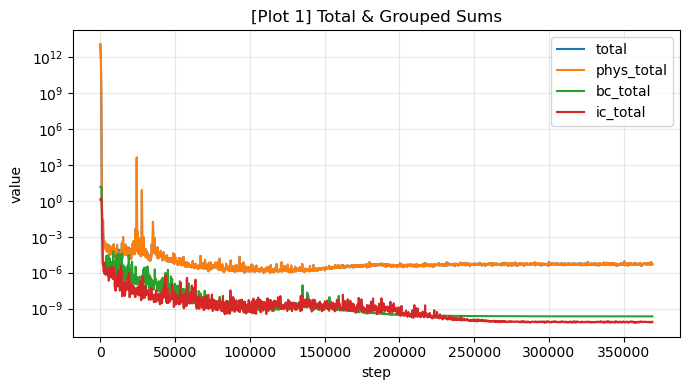

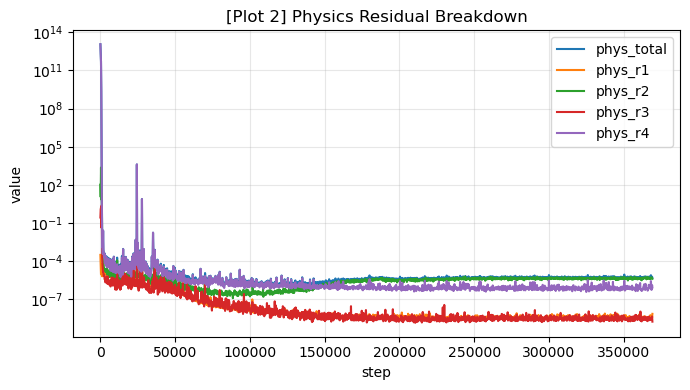

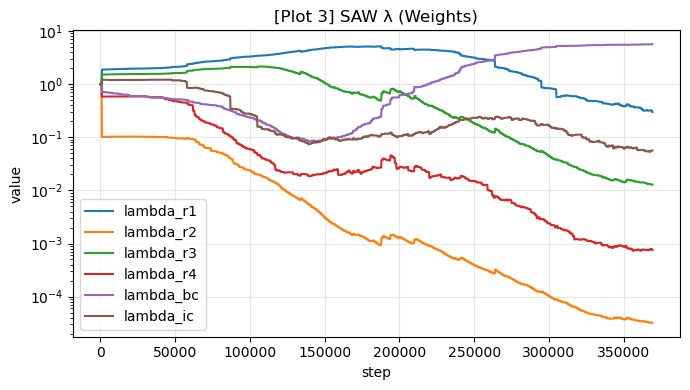

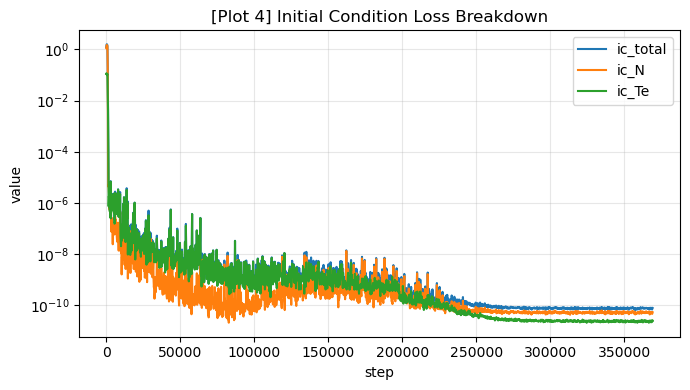

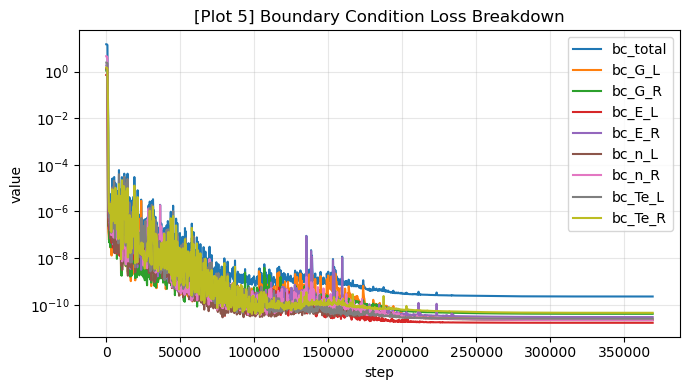

In [ ]:
%matplotlib inline
# =========================
# Common imports & helpers
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# Te 양수 보장 (모델 출력 Te_raw → 물리 Te)
Te_FLOOR = 1e-8
def Te_pos(te_raw):
    return jax.nn.softplus(te_raw) + Te_FLOOR


# =========================
# 1) log(list of tuples) → DataFrame
#    (우리가 바꾼 트레이닝 루프의 로그 형식에 맞춤)
#    - 필수 열: step, total, phys_L, phys_sum_unweighted,
#              phys_rn2, phys_rG2, phys_re2, phys_rE2,
#              bc_n_sum, bc_T_sum, data_sum, ic_sum
#    - ALB=uncertainty 이면 뒤에 sigma_* 5개가 추가됨
# =========================
def build_log_df(log):
    base_cols = [
        'step', 'total', 'phys_total', 'phys_r1', 'phys_r2', 'phys_r3', 'phys_r4',
        'lambda_r1','lambda_r2', 'lambda_r3', 'lambda_r4', 'lambda_bc', 'lambda_ic',
        'bc_total',
        'bc_G_L', 'bc_G_R', 'bc_E_L', 'bc_E_R',
        'bc_n_L', 'bc_n_R', 'bc_Te_L', 'bc_Te_R',
        'ic_total', 'ic_N', 'ic_Te',
    ]
    # sigma_cols = ['sigma_phys','sigma_bc_n','sigma_bc_T','sigma_data','sigma_ic']

    arr = []
    for row in log:
        arr.append([float(np.asarray(row[c])) for c in base_cols])

    # 길이에 따라 컬럼 구성
    ncol = len(arr[0]) if arr else 0
    # if ncol == len(base_cols) + len(sigma_cols):
        # cols = base_cols + sigma_cols
    if ncol == len(base_cols):
        cols = base_cols
    else:
        # 예상 밖이면 자동 생성
        cols = [f'col{i}' for i in range(ncol)]

    df = pd.DataFrame(arr, columns=cols)
    return df


# =========================
# 2) 공통 플로팅 유틸
# =========================
def plot_many(df, ycols, title, ylog=True):
    plt.figure(figsize=(7, 4))
    for c in ycols:
        if c not in df.columns:  # 없는 열은 건너뛴다
            continue
        plt.plot(df['step'], df[c], label=c)
    plt.xlabel('step'); plt.ylabel('value')
    if ylog:
        plt.yscale('log')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================
# 3) 로그 플롯 (요약 지표 위주)
# =========================
df_log = build_log_df(log)

plot_many(
    df_log,
    ['total', 'phys_total', 'bc_total', 'ic_total'],
    title='[Plot 1] Total & Grouped Sums', ylog=True
)

plot_many(
    df_log,
    ['phys_total','phys_r1','phys_r2','phys_r3','phys_r4'],
    title='[Plot 2] Physics Residual Breakdown', ylog=True
)

# σ는 ALB=uncertainty 일 때만 있음

plot_many(
    df_log,
    ['lambda_r1','lambda_r2', 'lambda_r3', 'lambda_r4', 'lambda_bc', 'lambda_ic'],
    title='[Plot 3] SAW λ (Weights)', ylog=True
)


plot_many(
    df_log,
    ['ic_total', 'ic_N', 'ic_Te'],
    title='[Plot 4] Initial Condition Loss Breakdown', ylog=True
)

plot_many(
    df_log,
    ['bc_total',
        'bc_G_L', 'bc_G_R', 'bc_E_L', 'bc_E_R',
        'bc_n_L', 'bc_n_R', 'bc_Te_L', 'bc_Te_R'],
    title='[Plot 5] Boundary Condition Loss Breakdown', ylog=True
)


In [ ]:
# ============================================
# ICP 1D – PINN vs C-sim 시각화 유틸
#   - Heatmaps (부분 영역)
#   - z-프로파일 @ 특정 시간 (ni, Te, E, Γ)
#   - 시간 시계열 @ 특정 z (ni, Te, E, Γ)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# -----------------------------
# Plot style (공통)
# -----------------------------
f_supt = 40
f_title = 25
f_label = 20
f_legend = 20
f_tick = 20
l_w_ex = 3.5
l_w_pred = 3.5
pad_xy = 8   # tick padding

# -----------------------------
# 0. CSV → 격자 + 행렬, PINN 격자 평가
# -----------------------------
def _sim_grid_and_mats(data_path):
    """
    Return (times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat) on the CSV grid,
    already non-dimensionalized by t0, l0 and shaped (Nt, Nz).
    - times_bar: time[s] / t0
    - zs_bar   : z[m]    / l0
    - *_mat    : 무차원 변수 (예: ni_norm, Te_norm 등)
    """
    df = pd.read_csv(data_path)
    times_bar = np.sort(df['time[s]'].unique()) / t0   # (Nt,)
    zs_bar    = np.sort(df['z[m]'].unique())    / l0   # (Nz,)

    Ni_mat = df.pivot(index='time[s]', columns='z[m]', values='ni_norm').to_numpy()
    Te_mat = df.pivot(index='time[s]', columns='z[m]', values='Te_norm').to_numpy()
    E_mat  = df.pivot(index='time[s]', columns='z[m]', values='E_norm' ).to_numpy()
    G_mat  = df.pivot(index='time[s]', columns='z[m]', values='Fi_norm').to_numpy()
    return times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat


def _pinn_on_grid(state, times_bar, zs_bar):
    """
    Evaluate model on the given (times_bar, zs_bar) grid → (Nt,Nz) maps.
    Input:
      times_bar: (Nt,)  (무차원 t̄ = t/t0)
      zs_bar   : (Nz,)  (무차원 z̄ = z/l0)
    Output:
      n_hat  : (Nt,Nz) 무차원 ni_bar
      Te_hat : (Nt,Nz) 무차원 Te_bar
      E_hat  : (Nt,Nz)
      G_hat  : (Nt,Nz)
    """
    t_grid, z_grid = jnp.meshgrid(times_bar, zs_bar, indexing='ij')
    t_flat = t_grid.ravel()
    z_flat = z_grid.ravel()

    Nf, Tf, Ef, Gf = jax.vmap(
        lambda tt, zz: model_apply(state.params['nn'], tt, zz)
    )(t_flat, z_flat)

    n_hat  = np.asarray(jnp.exp(Nf).reshape(len(times_bar), len(zs_bar)))
    Te_hat = np.asarray(Tf.reshape(len(times_bar), len(zs_bar)))
    E_hat  = np.asarray(Ef.reshape(len(times_bar), len(zs_bar)))
    G_hat  = np.asarray(Gf.reshape(len(times_bar), len(zs_bar)))
    return n_hat, Te_hat, E_hat, G_hat

# =====================================================
# 1) 부분 영역 field maps: Exact / PINN / |diff| (ni, Te, E, Γ)
# =====================================================
def compare_field_maps_subset(
    state,
    data_path,
    # index 범위 (inclusive). None이면 전체.
    t_idx=None, z_idx=None,
    # 또는 물리 좌표 범위(SI). 지정되면 index 범위보다 우선.
    t_s=None, z_m=None,
    # 다운샘플링 stride
    t_step=1, z_step=1,
    # error 표시 여부
    show_error=True,
):
    """
    Plot Exact vs PINN vs |diff| on a subgrid selected by either:
      - indices: t_idx=(i0,i1), z_idx=(k0,k1)  [inclusive]
      - physical ranges: t_s=(t_min_s, t_max_s) in seconds, z_m=(z_min_m, z_max_m) in meters
    and down-sampled by strides t_step, z_step.
    """
    times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat = _sim_grid_and_mats(data_path)

    def _pick_indices(axis_vals_bar, idx_range, val_range_SI, scale_SI):
        N = len(axis_vals_bar)
        # 1) SI 값으로 범위 지정
        if val_range_SI is not None:
            v0, v1 = val_range_SI
            a0 = v0 / scale_SI
            a1 = v1 / scale_SI
            i0 = int(np.searchsorted(axis_vals_bar, a0, side='left'))
            i1 = int(np.searchsorted(axis_vals_bar, a1, side='right')) - 1
        # 2) 인덱스로 범위 지정
        elif idx_range is not None:
            i0, i1 = idx_range
            if i0 is None: i0 = 0
            if i1 is None: i1 = N - 1
        # 3) 전체
        else:
            i0, i1 = 0, N - 1

        i0 = max(0, min(i0, N-1))
        i1 = max(0, min(i1, N-1))
        if i0 > i1:
            i0, i1 = i1, i0
        return i0, i1

    # 시/공간 범위 선택
    ti0, ti1 = _pick_indices(times_bar, t_idx, t_s, t0)
    zi0, zi1 = _pick_indices(zs_bar,    z_idx, z_m, l0)

    t_sel_bar = times_bar[ti0:ti1+1:t_step]
    z_sel_bar = zs_bar   [zi0:zi1+1:z_step]

    Ni_sub = Ni_mat[ti0:ti1+1:t_step, zi0:zi1+1:z_step]
    Te_sub = Te_mat[ti0:ti1+1:t_step, zi0:zi1+1:z_step]
    E_sub  = E_mat [ti0:ti1+1:t_step, zi0:zi1+1:z_step]
    G_sub  = G_mat [ti0:ti1+1:t_step, zi0:zi1+1:z_step]

    # PINN prediction on subset grid
    n_hat, Te_hat, E_hat, G_hat = _pinn_on_grid(state, t_sel_bar, z_sel_bar)

    # Errors (abs diff)
    Ni_err = np.abs(Ni_sub - n_hat)
    Te_err = np.abs(Te_sub - Te_hat)
    E_err  = np.abs(E_sub  - E_hat )
    G_err  = np.abs(G_sub  - G_hat )

    def _triple(fig_title, exact, pred, err, zs_bar_sub, ts_bar_sub, cbar_label):
        cols = 3 if show_error else 2
        fig, axs = plt.subplots(1, cols, figsize=(6*cols, 5))
        fig.suptitle(fig_title, fontsize=f_supt)

        # Exact
        im0 = axs[0].pcolormesh(zs_bar_sub*l0, ts_bar_sub*t0, exact, shading='auto')
        axs[0].set_title('Exact', fontsize=f_title)
        axs[0].set_xlabel('z [m]', fontsize=f_label)
        axs[0].set_ylabel('t [s]', fontsize=f_label)
        cbar0 = fig.colorbar(im0, ax=axs[0])
        cbar0.ax.tick_params(labelsize=f_tick)
        cbar0.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        cbar0.ax.yaxis.get_offset_text().set_fontsize(f_tick)
        axs[0].tick_params(axis='x', labelsize=f_tick, pad=pad_xy)
        axs[0].tick_params(axis='y', labelsize=f_tick, pad=pad_xy)

        # PINN
        im1 = axs[1].pcolormesh(zs_bar_sub*l0, ts_bar_sub*t0, pred, shading='auto')
        axs[1].set_title('PINN', fontsize=f_title)
        axs[1].set_xlabel('z [m]', fontsize=f_label)
        axs[1].set_ylabel('t [s]', fontsize=f_label)
        cbar1 = fig.colorbar(im1, ax=axs[1])
        cbar1.ax.tick_params(labelsize=f_tick)
        cbar1.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        cbar1.ax.yaxis.get_offset_text().set_fontsize(f_tick)
        axs[1].tick_params(axis='x', labelsize=f_tick, pad=pad_xy)
        axs[1].tick_params(axis='y', labelsize=f_tick, pad=pad_xy)

        # Error (optional)
        if show_error:
            im2 = axs[2].pcolormesh(zs_bar_sub*l0, ts_bar_sub*t0, err, shading='auto')
            axs[2].set_title(r'$|{\rm Exact} - {\rm PINN}|$', fontsize=f_title)
            axs[2].set_xlabel('z [m]', fontsize=f_label)
            axs[2].set_ylabel('t [s]', fontsize=f_label)
            cbar2 = fig.colorbar(im2, ax=axs[2])
            cbar2.ax.tick_params(labelsize=f_tick)
            cbar2.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
            cbar2.ax.yaxis.get_offset_text().set_fontsize(f_tick)
            axs[2].tick_params(axis='x', labelsize=f_tick, pad=pad_xy)
            axs[2].tick_params(axis='y', labelsize=f_tick, pad=pad_xy)

        fig.tight_layout()
        plt.show()

    _triple(r"Ion Density $n_i$",     Ni_sub*n0, n_hat*n0, Ni_err*n0, z_sel_bar, t_sel_bar, r"$n_i$")
    _triple(r"Electron Temperature $T_e$", Te_sub*T0, Te_hat*T0, Te_err*T0, z_sel_bar, t_sel_bar, r"$T_e$")
    _triple(r"Electric Field $E$",          E_sub,    E_hat,    E_err,      z_sel_bar, t_sel_bar, r"$E$")
    _triple(r"Ion Flux $\Gamma$",           G_sub,    G_hat,    G_err,      z_sel_bar, t_sel_bar, r"$\Gamma$")

# =====================================================
# 2) z-방향 snapshot (특정 시각): ni, Te, E, Γ (2×2)
# =====================================================
def _profiles_vs_z_snapshot(state, data_path, t_query_s, title_prefix="Snapshot"):
    """
    C-sim vs PINN profiles over z at a given physical time t_query_s [s].
    → 2×2 subplot: ni, Te, E, Γ
    """
    times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat = _sim_grid_and_mats(data_path)
    z_SI = zs_bar * l0

    # 가장 가까운 무차원 시각 인덱스
    t_bar = t_query_s / t0
    idx = int(np.clip(np.searchsorted(times_bar, t_bar), 0, len(times_bar)-1))
    t_SI = times_bar[idx] * t0

    # C-sim 프로파일 (무차원 → 물리)
    ni_sim_bar = Ni_mat[idx, :]
    Te_sim_bar = Te_mat[idx, :]
    E_sim      = E_mat[idx, :]
    G_sim      = G_mat[idx, :]

    ni_sim = ni_sim_bar * n0
    Te_sim = Te_sim_bar * T0

    # PINN 예측 (무차원 입력)
    t_vec_bar = jnp.full((len(zs_bar),), times_bar[idx])
    z_vec_bar = jnp.array(zs_bar)
    N_hat_prof, Te_hat_prof, E_hat_prof, G_hat_prof = model_apply(
        state.params['nn'], t_vec_bar, z_vec_bar
    )

    ni_pinn = np.asarray(jnp.exp(N_hat_prof)) * n0
    Te_pinn = np.asarray(Te_hat_prof) * T0
    E_pinn  = np.asarray(E_hat_prof)
    G_pinn  = np.asarray(G_hat_prof)

    # ---- Plot 2×2 ----
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{title_prefix} @ t = {t_SI:.2e} s", fontsize=f_supt)

    # n_i
    ax = axs[0, 0]
    ax.plot(z_SI, ni_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, ni_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$n_i\,[m^{-3}]$', fontsize=f_label)
    ax.set_title(r'Ion density $n_i$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)
    ax.yaxis.get_offset_text().set_fontsize(f_tick)

    # T_e
    ax = axs[0, 1]
    ax.plot(z_SI, Te_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, Te_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$T_e$', fontsize=f_label)
    ax.set_title(r'Electron temperature $T_e$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(f_tick)

    # E
    ax = axs[1, 0]
    ax.plot(z_SI, E_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, E_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$E$', fontsize=f_label)
    ax.set_title(r'Electric field $E$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    # Γ
    ax = axs[1, 1]
    ax.plot(z_SI, G_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(z_SI, G_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('z [m]', fontsize=f_label)
    ax.set_ylabel(r'$\Gamma$', fontsize=f_label)
    ax.set_title(r'Ion flux $\Gamma$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def compare_profiles_t0(state, data_path):
    """초기조건 시각 t_min에서 ni, Te, E, Γ를 2×2로 비교."""
    df = pd.read_csv(data_path)
    t0_SI = df['time[s]'].min()
    _profiles_vs_z_snapshot(state, data_path, t_query_s=t0_SI,
                            title_prefix="Initial condition")


def compare_profiles_tfinal(state, data_path):
    """최종 시각 t_max(steady-state 근사)에서 ni, Te, E, Γ를 2×2로 비교."""
    df = pd.read_csv(data_path)
    t_star_SI = df['time[s]'].max()
    _profiles_vs_z_snapshot(state, data_path, t_query_s=t_star_SI,
                            title_prefix="Steady state")


def compare_profiles_at_time(state, data_path, t_query_s_list):
    """
    Plot C-sim vs PINN profiles over z at specific time(s) in seconds.
    → 각 t에 대해 ni, Te, E, Γ 4개 변수를 2×2 subplot으로 그림.
    - t_query_s_list: float 또는 float 리스트 [초 단위]
    """
    if not isinstance(t_query_s_list, (list, tuple, np.ndarray)):
        t_query_s_list = [t_query_s_list]

    for t_s in t_query_s_list:
        _profiles_vs_z_snapshot(state, data_path, t_query_s=t_s,
                                title_prefix="Snapshot")

# =====================================================
# 3) 특정 z에서 시간 시리즈: ni(t), Te(t), E(t), Γ(t) (2×2)
# =====================================================
def _time_series_at_z(state, data_path, z_query_m, title_prefix="Time series"):
    """
    Temporal profiles at a given spatial location z_query_m [m]:
    ni(t), Te(t), E(t), Γ(t) for C-sim and PINN (2×2 subplot).
    """
    times_bar, zs_bar, Ni_mat, Te_mat, E_mat, G_mat = _sim_grid_and_mats(data_path)
    t_SI = times_bar * t0

    # 가장 가까운 z index
    z_bar = z_query_m / l0
    k = int(np.clip(np.searchsorted(zs_bar, z_bar), 0, len(zs_bar)-1))
    z_SI = zs_bar[k] * l0

    # C-sim time series
    ni_sim_bar = Ni_mat[:, k]
    Te_sim_bar = Te_mat[:, k]
    E_sim      = E_mat[:, k]
    G_sim      = G_mat[:, k]

    ni_sim = ni_sim_bar * n0
    Te_sim = Te_sim_bar * T0

    # PINN time series (무차원 입력)
    t_vec_bar = jnp.array(times_bar)
    z_vec_bar = jnp.full((len(times_bar),), zs_bar[k])
    N_hat, Te_hat, E_hat, G_hat = model_apply(state.params['nn'], t_vec_bar, z_vec_bar)

    ni_pinn = np.asarray(jnp.exp(N_hat)) * n0
    Te_pinn = np.asarray(Te_hat) * T0
    E_pinn  = np.asarray(E_hat)
    G_pinn  = np.asarray(G_hat)

    # ---- Plot 2×2 ----
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{title_prefix} @ z ≈ {z_SI:.3e} m", fontsize=f_supt)

    # n_i(t)
    ax = axs[0, 0]
    ax.plot(t_SI, ni_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(t_SI, ni_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('t [s]', fontsize=f_label)
    ax.set_ylabel(r'$n_i\,[m^{-3}]$', fontsize=f_label)
    ax.set_title(r'Ion density $n_i(t)$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)
    ax.yaxis.get_offset_text().set_fontsize(f_tick)

    # T_e(t)
    ax = axs[0, 1]
    ax.plot(t_SI, Te_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(t_SI, Te_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('t [s]', fontsize=f_label)
    ax.set_ylabel(r'$T_e$', fontsize=f_label)
    ax.set_title(r'Electron temperature $T_e(t)$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(f_tick)

    # E(t)
    ax = axs[1, 0]
    ax.plot(t_SI, E_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(t_SI, E_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('t [s]', fontsize=f_label)
    ax.set_ylabel(r'$E$', fontsize=f_label)
    ax.set_title(r'Electric field $E(t)$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    # Γ(t)
    ax = axs[1, 1]
    ax.plot(t_SI, G_sim, 'o', linestyle='', lw=l_w_ex, label='Exact')
    ax.plot(t_SI, G_pinn, '-', lw=l_w_ex, label='PINN')
    ax.set_xlabel('t [s]', fontsize=f_label)
    ax.set_ylabel(r'$\Gamma$', fontsize=f_label)
    ax.set_title(r'Ion flux $\Gamma(t)$', fontsize=f_title)
    ax.legend(fontsize=f_legend)
    ax.tick_params(labelsize=f_tick)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def compare_spatial_slice_at_z(state, data_path, z_query_m):
    """
    Wrapper: 4개 변수(ni, Te, E, Γ)를 시계열로 2×2 subplot에 표시.
    """
    _time_series_at_z(state, data_path, z_query_m,
                      title_prefix="Time series")


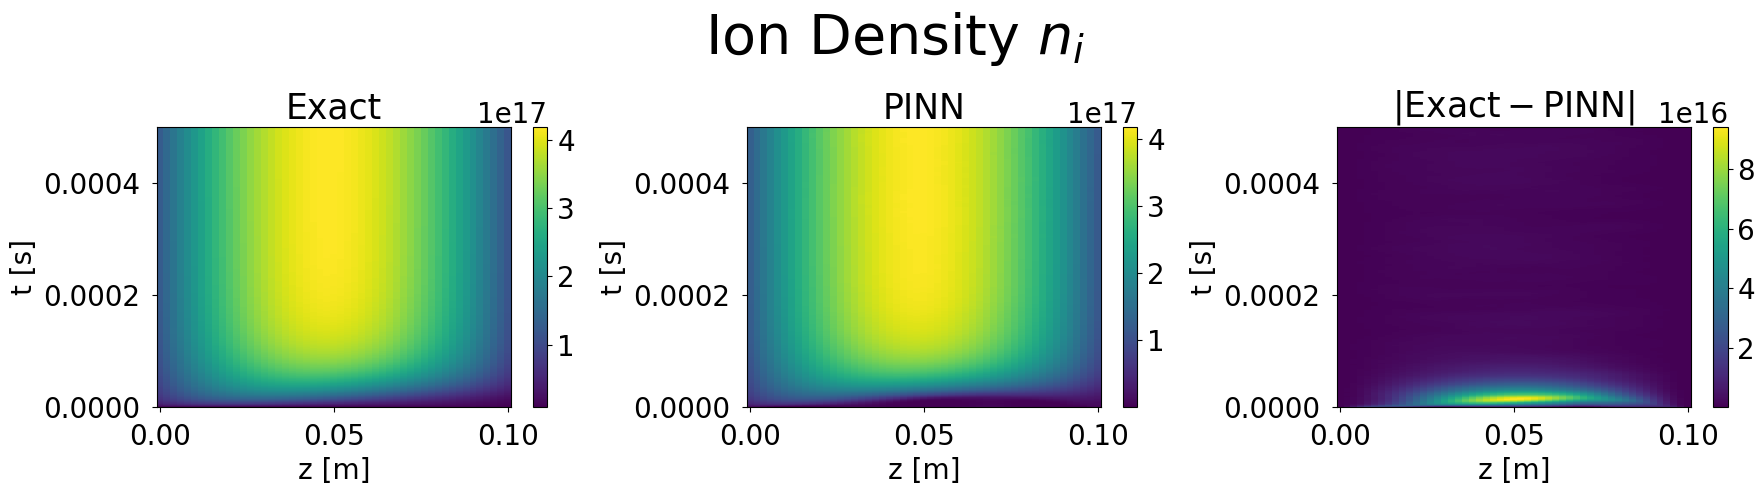

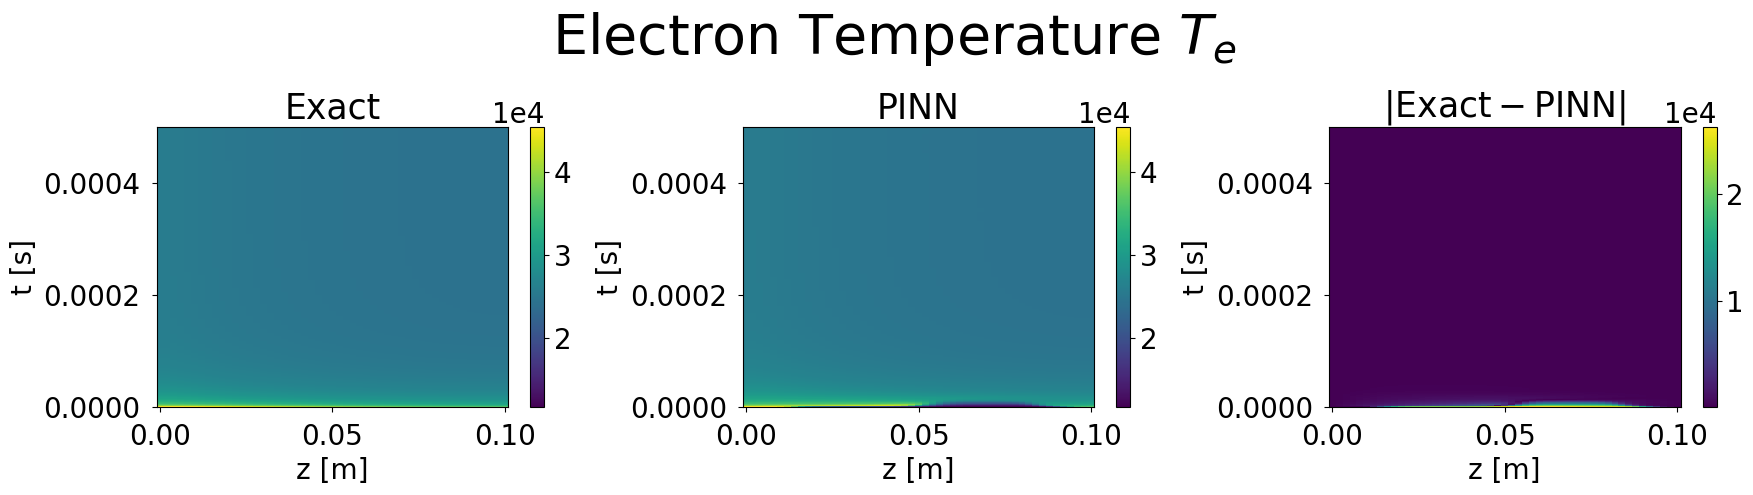

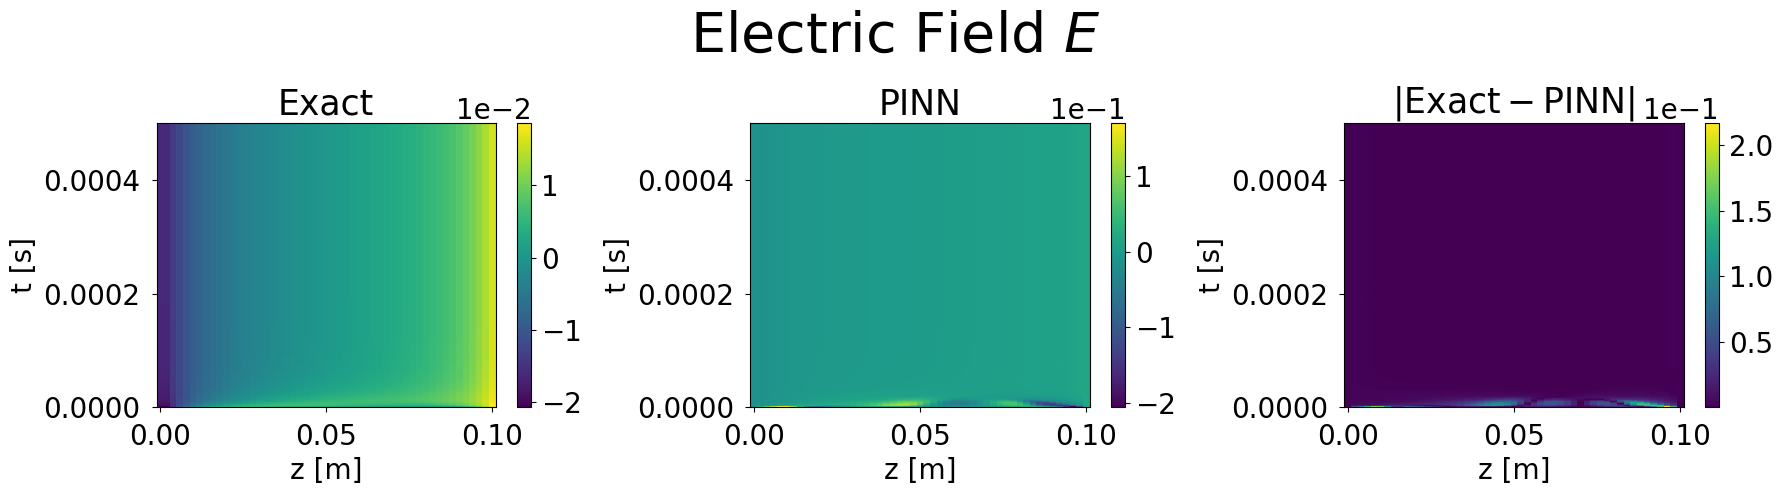

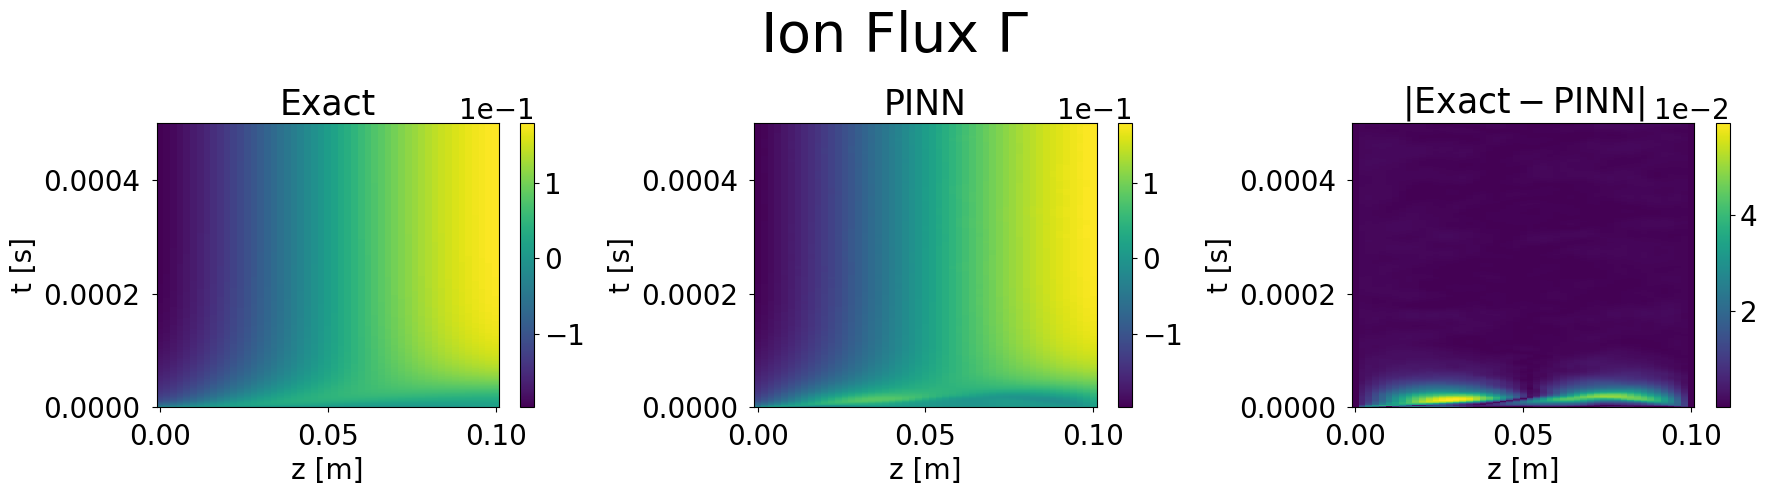

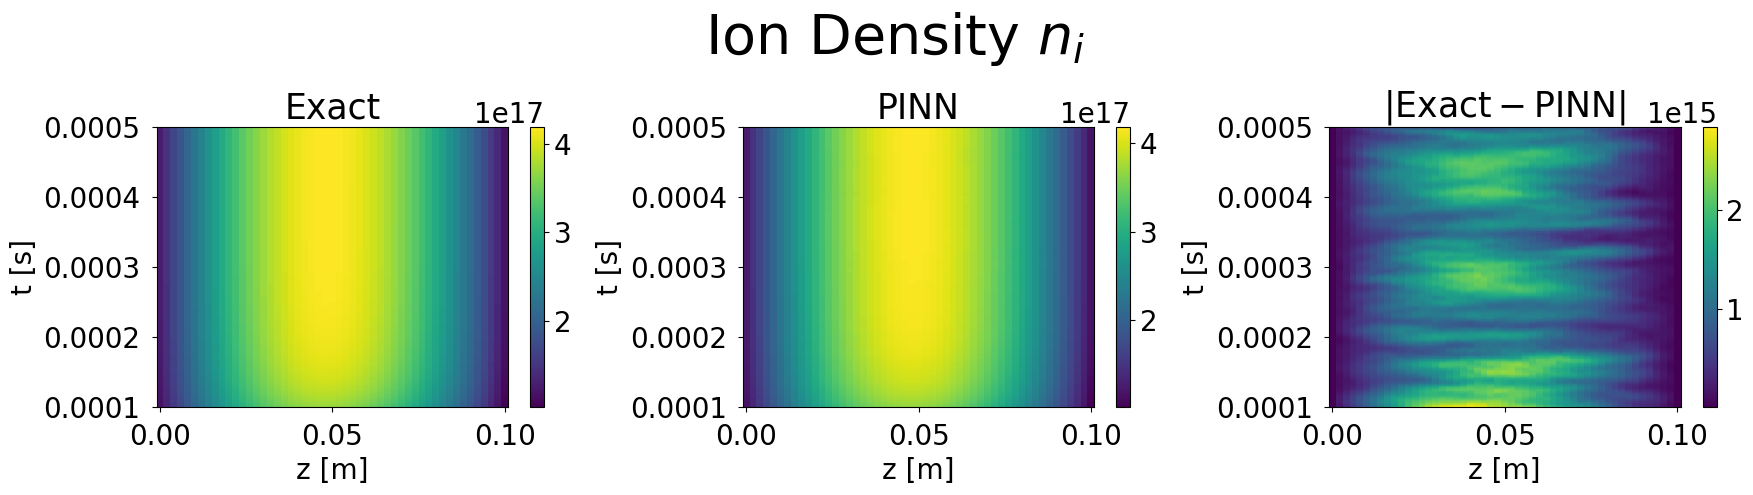

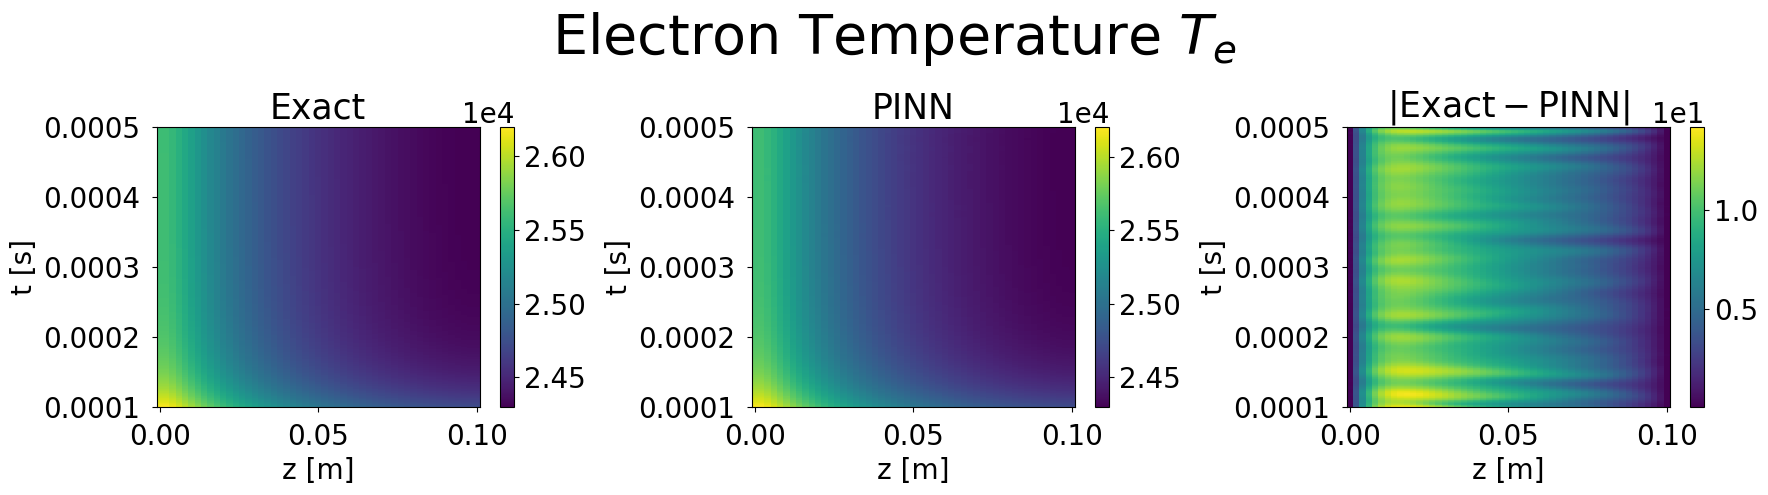

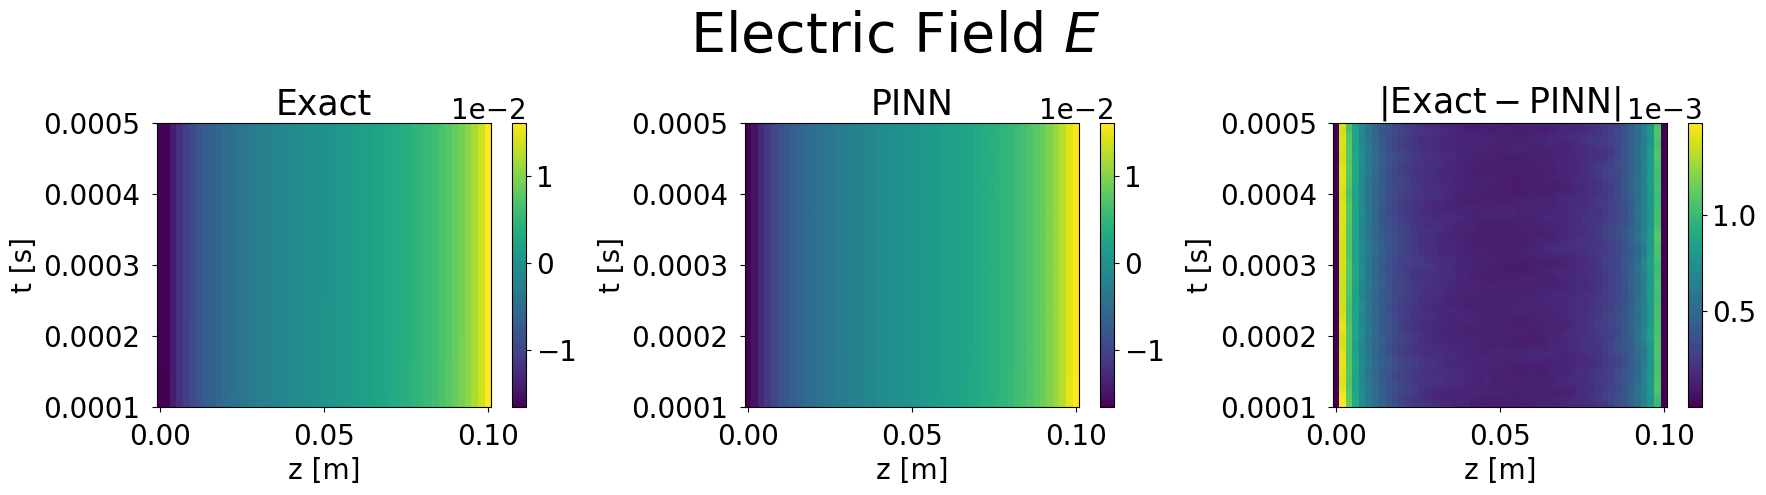

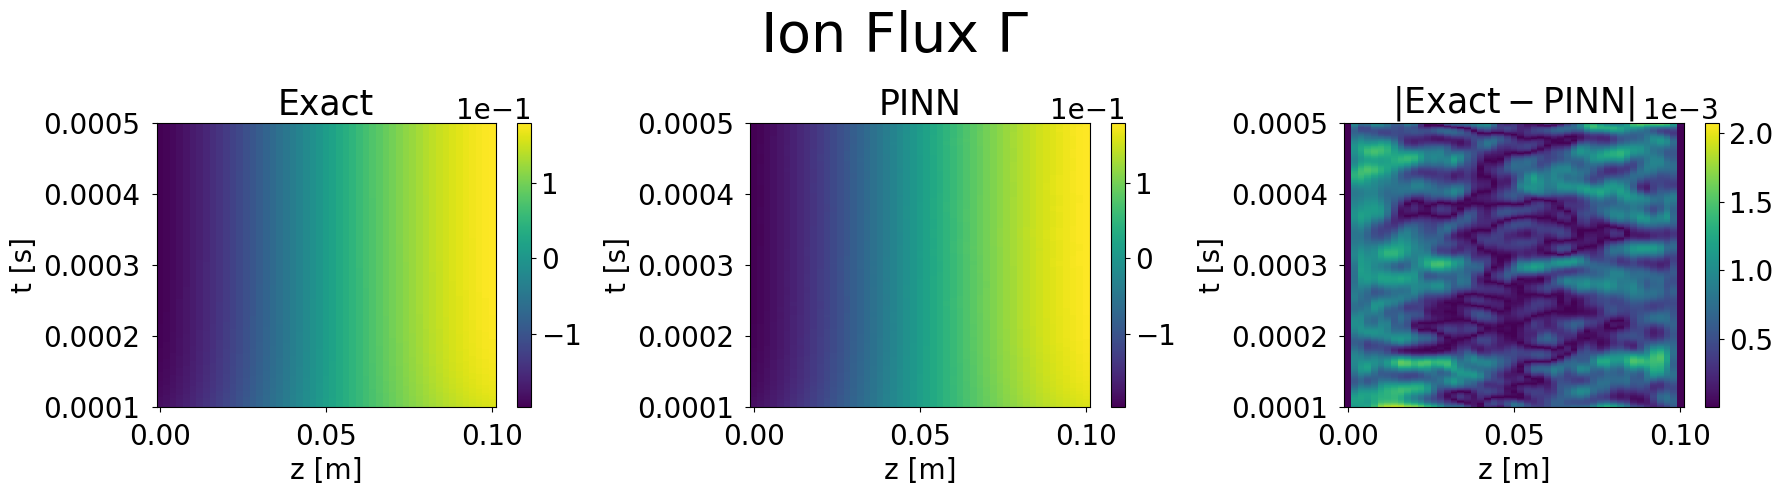

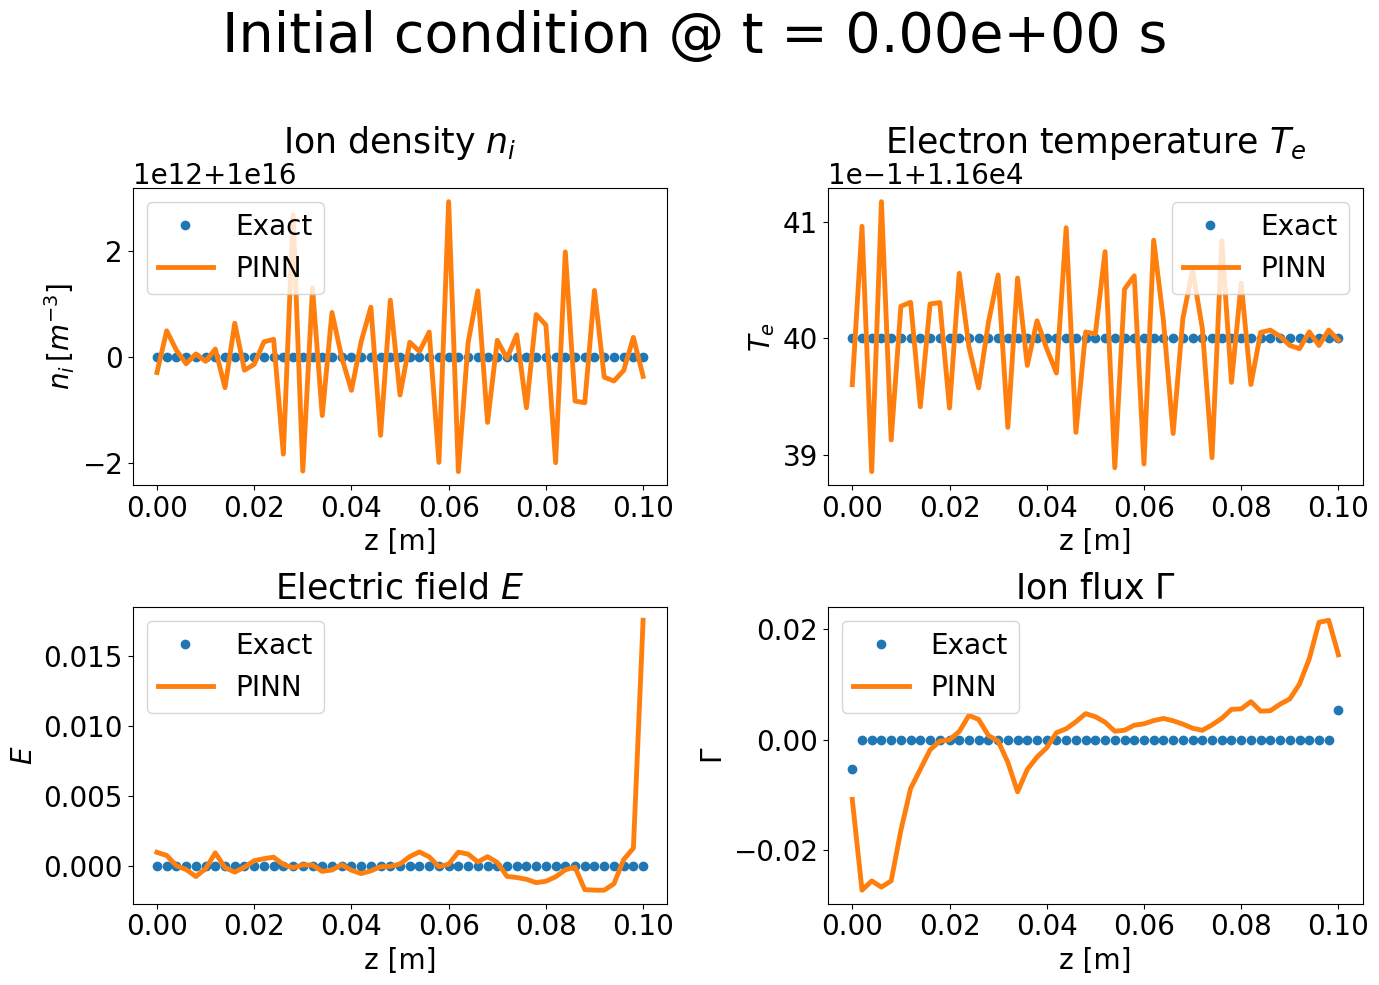

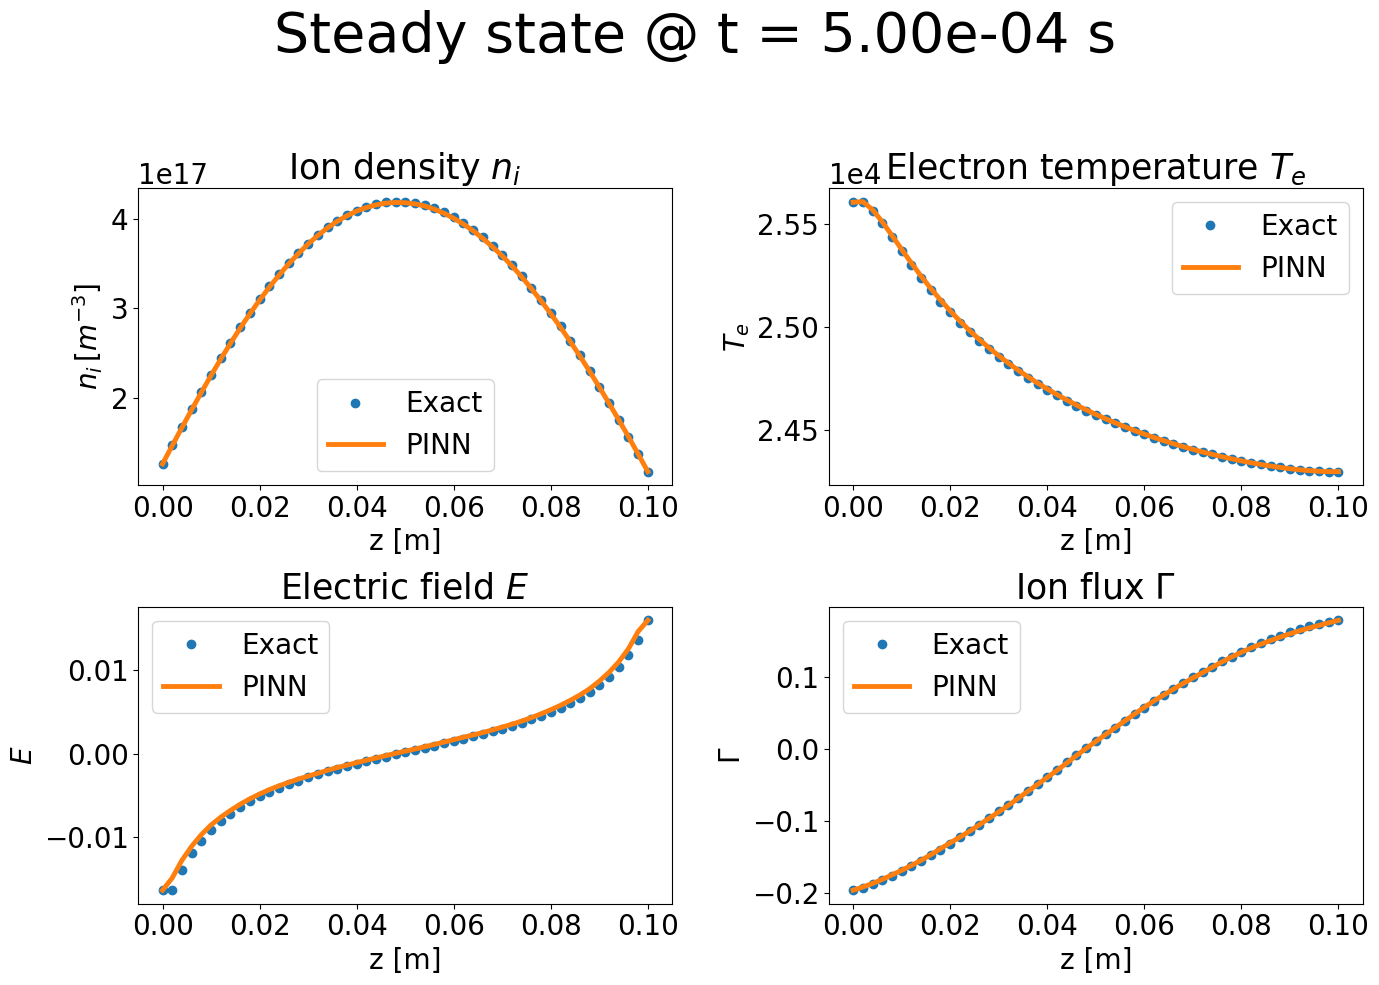

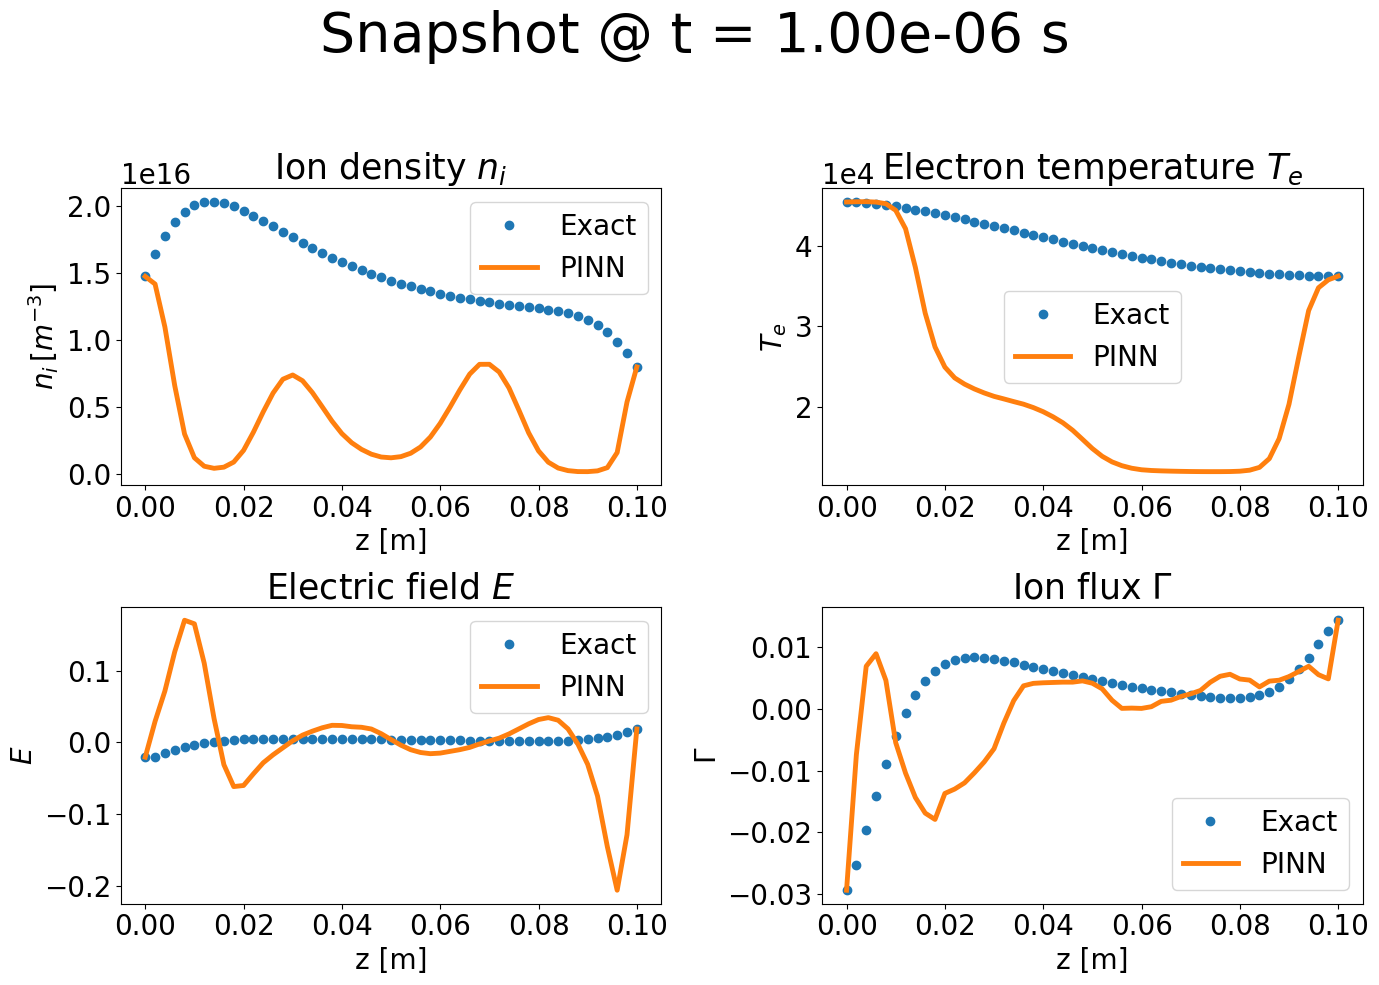

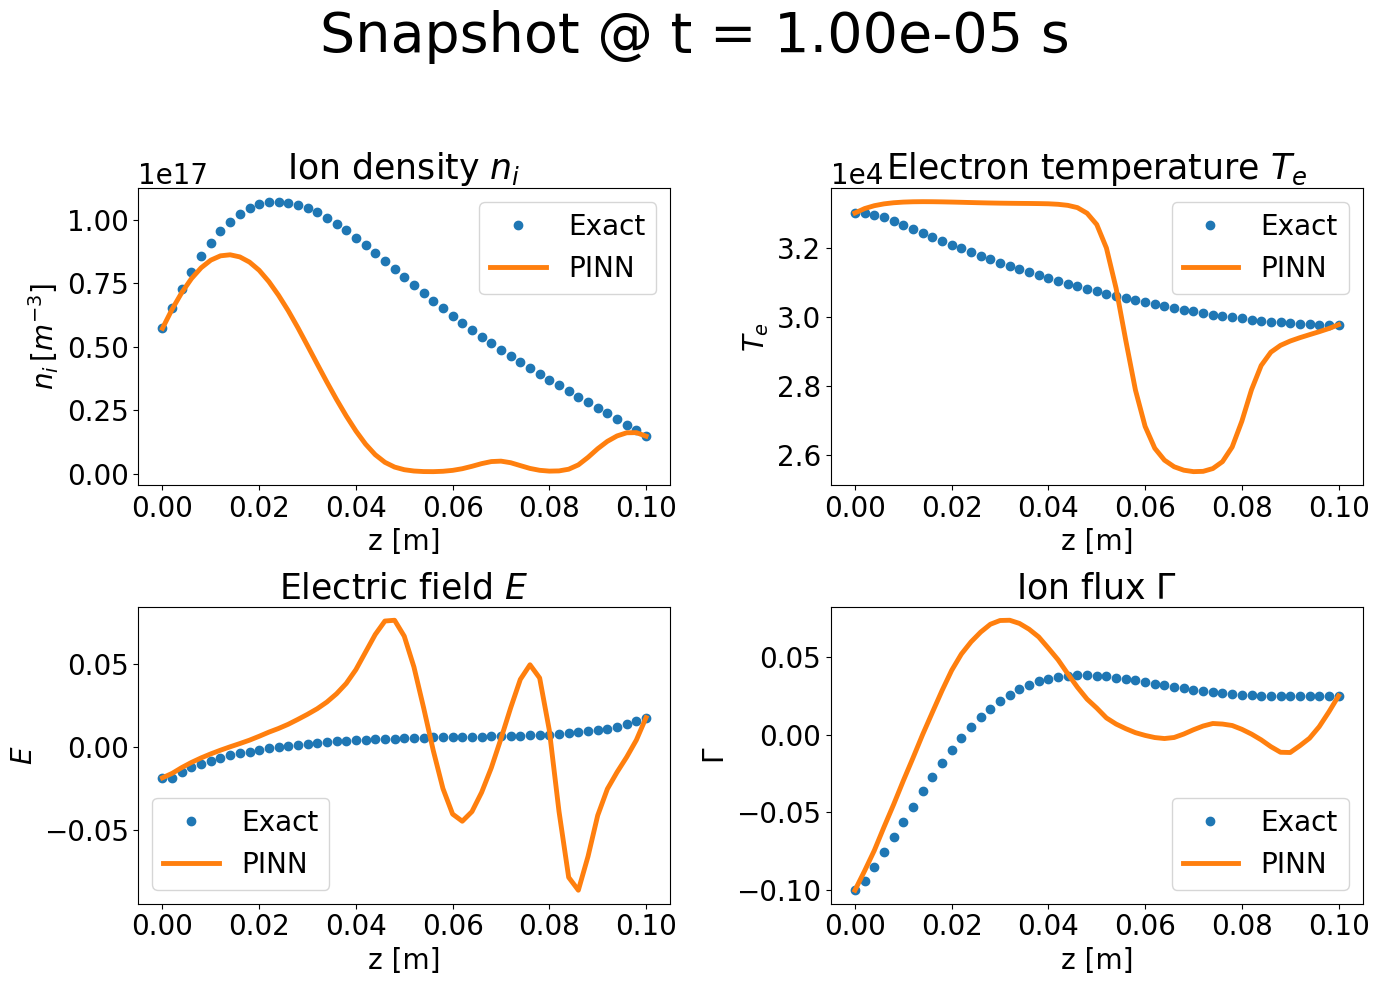

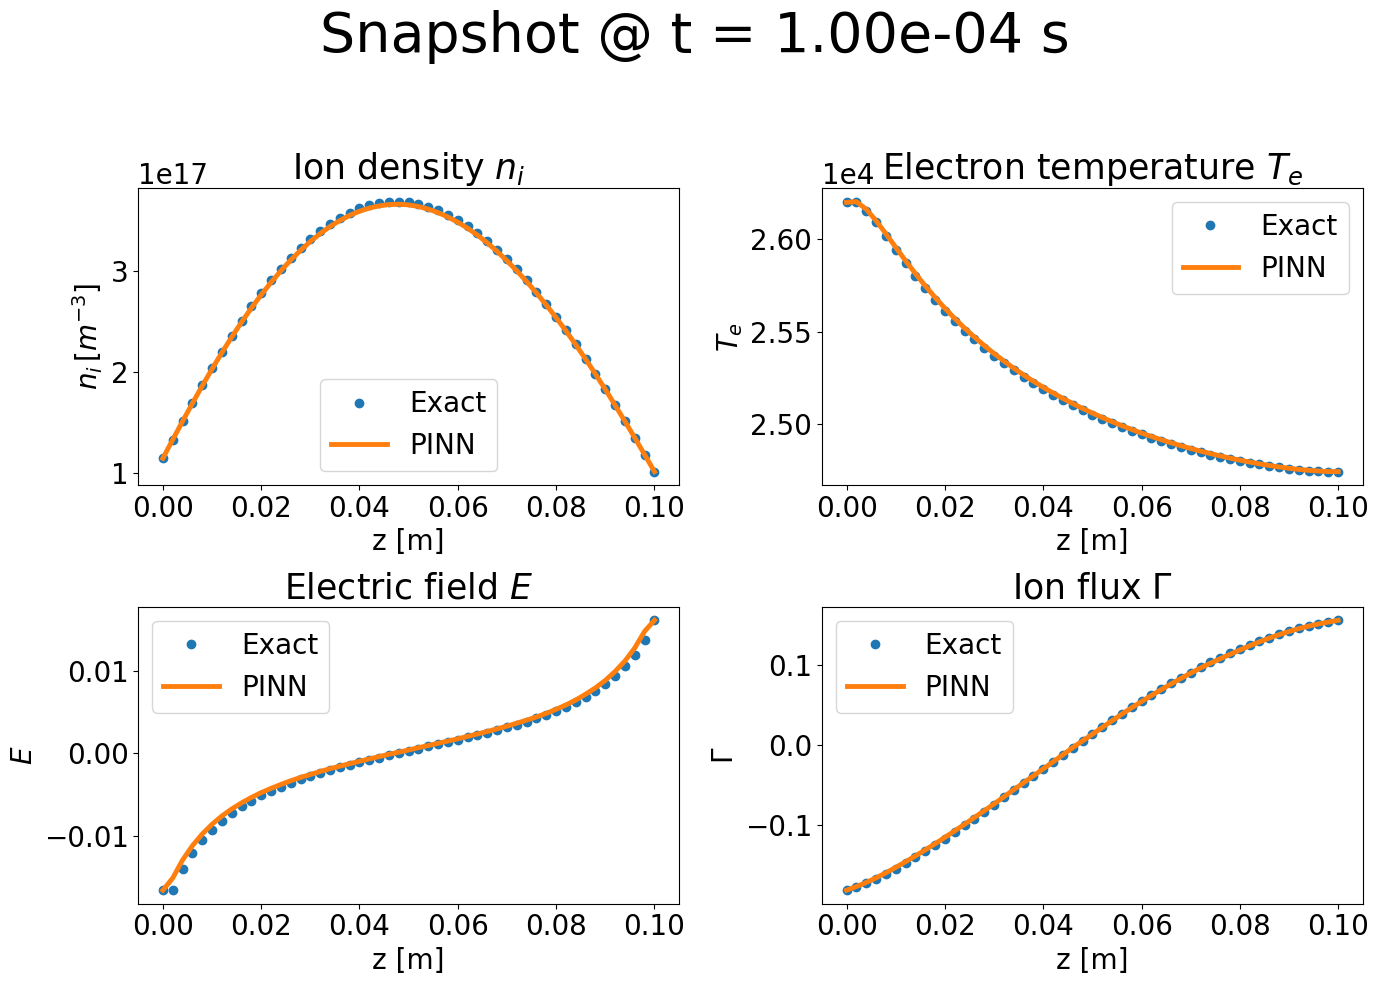

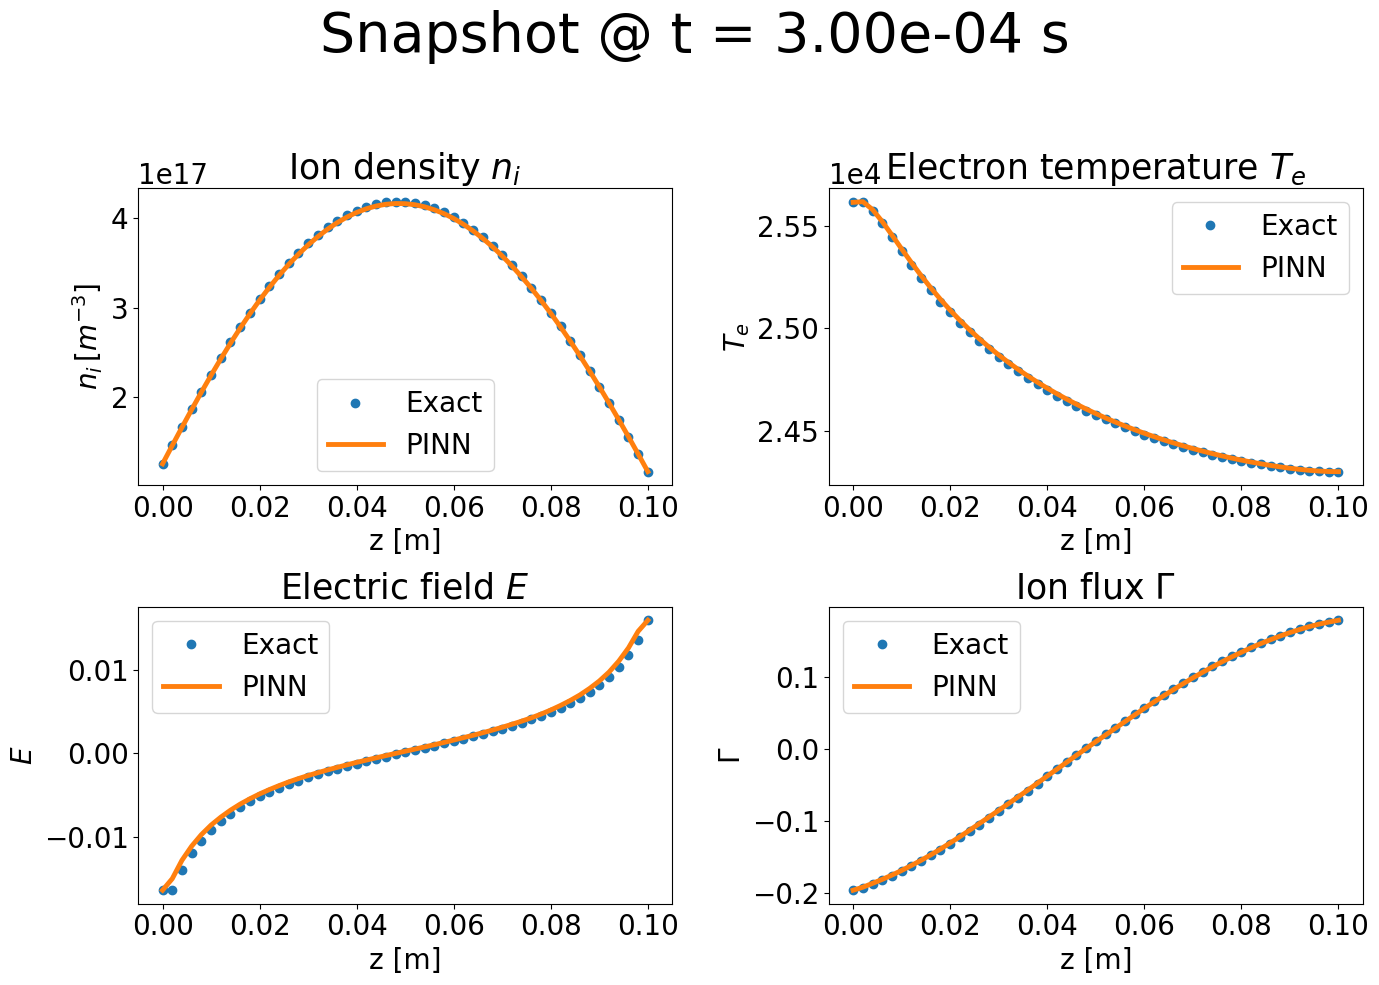

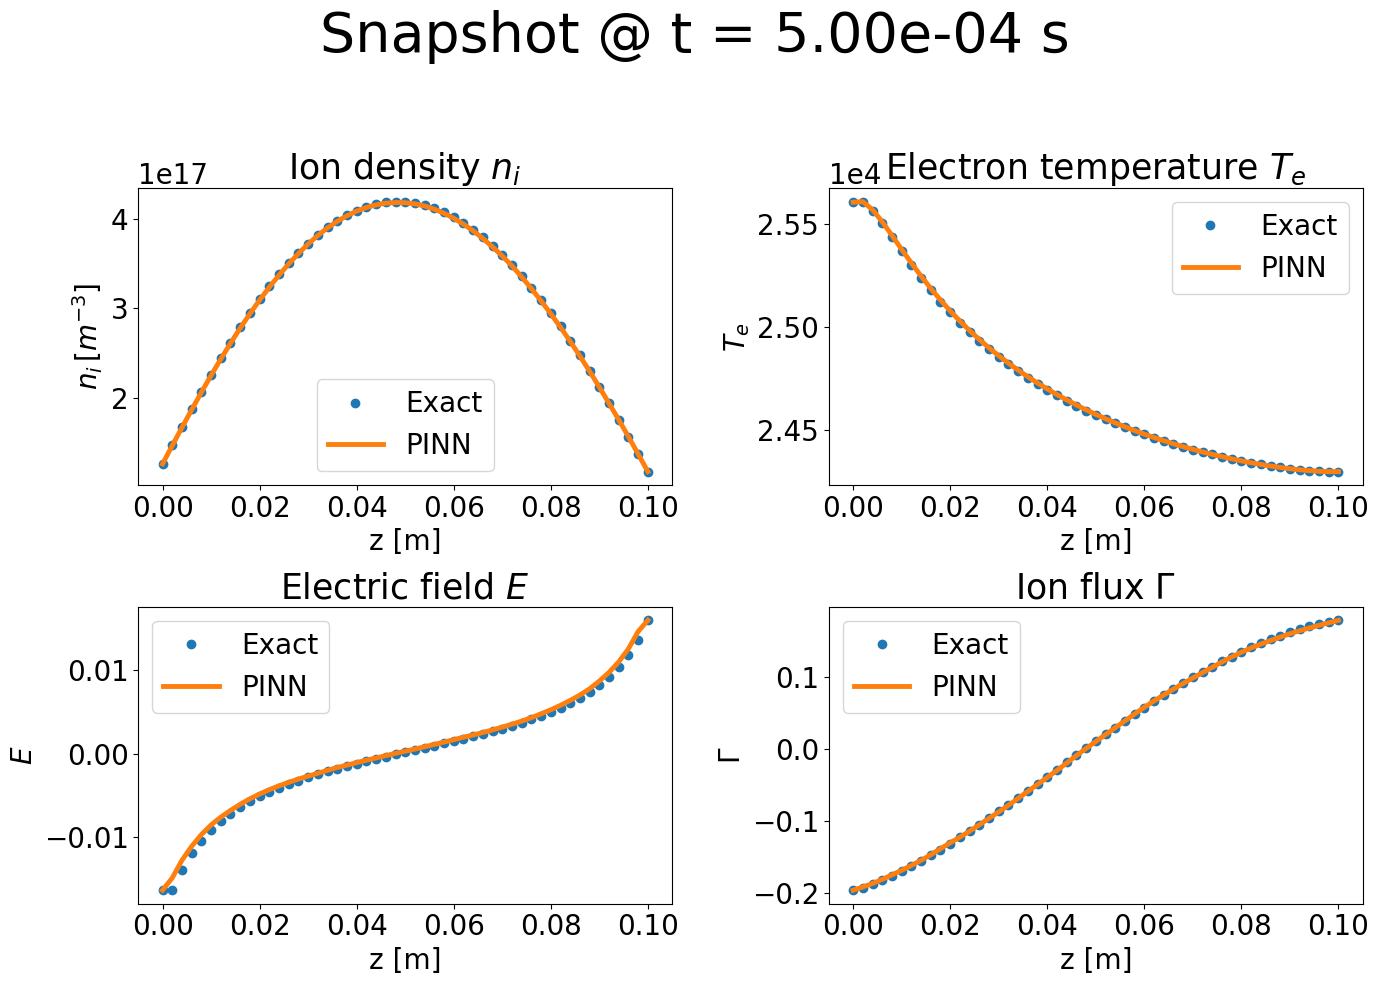

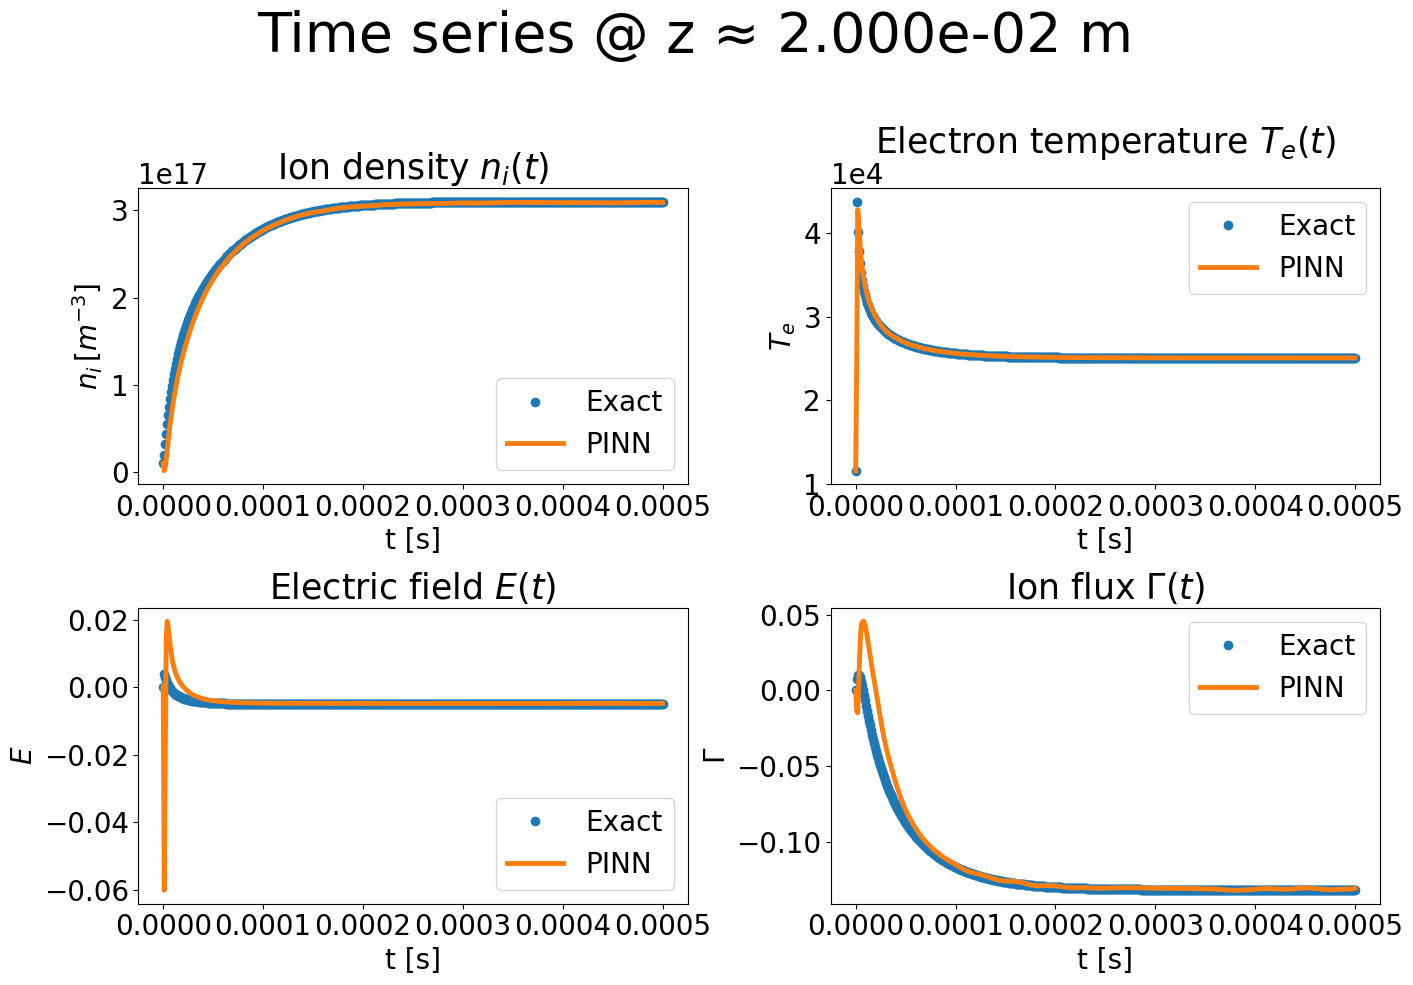

In [ ]:

# 1) 특정 구간 heatmap (예: t=0~전체, z=0~전체, 에러 포함)
compare_field_maps_subset(state, data_path,
                          t_idx=None, z_idx=None,
                          t_s=None, z_m=None,
                          t_step=1, z_step=1,
                          show_error=True)

compare_field_maps_subset(state, data_path,
                          t_idx=(100, None), z_idx=None,
                          t_s=None, z_m=None,
                          t_step=1, z_step=1,
                          show_error=True)

# 2) 초기조건 / 최종시각 snapshot (z-프로파일)
compare_profiles_t0(state, data_path)
compare_profiles_tfinal(state, data_path)

# 3) 임의 시각 snapshot (여러 개도 가능)
check_time = [1.0e-6, 1.0e-5, 1.0e-4, 3.0e-4, 5.0e-4]  # seconds
compare_profiles_at_time(state, data_path, t_query_s_list=check_time)

# 4) 특정 z에서 시간 시리즈 (예: z=2cm)
compare_spatial_slice_at_z(state, data_path, z_query_m=0.02)


In [13]:
import os
from PIL import Image
from natsort import natsorted

# ===== 사용자 설정 =====
ROOT = "/workspace/CODE/ICP/time-dependent/grad_norm_update"
STEP_PREFIX = "step_"
FPS = 10  # 초당 프레임 (= 학습 step이 바뀌는 속도)
OUT_DIR = os.path.join(ROOT, "gifs_by_time")  # GIF 저장 폴더

os.makedirs(OUT_DIR, exist_ok=True)

# ===== 1) step_* 폴더 정렬해서 수집 =====
step_dirs = [
    os.path.join(ROOT, d)
    for d in os.listdir(ROOT)
    if d.startswith(STEP_PREFIX) and os.path.isdir(os.path.join(ROOT, d))
]
step_dirs = natsorted(step_dirs)

print(f"[INFO] Found {len(step_dirs)} step directories.")

if len(step_dirs) == 0:
    raise RuntimeError("step_* 폴더를 찾지 못했습니다.")

# ===== 2) 사용할 시간 목록 자동 추출 =====
# 첫 번째 step 폴더를 기준으로 profiles_t_*.png 파일에서 시간 문자열만 뽑음
first_step = step_dirs[0]
time_files = [
    f for f in os.listdir(first_step)
    if f.startswith("profiles_t_") and f.endswith(".png")
]

if len(time_files) == 0:
    raise RuntimeError(f"{first_step} 안에서 profiles_t_*.png 를 찾지 못했습니다.")

# 예: "profiles_t_1e-06.png" -> "1e-06"
time_strings = sorted(
    {fname[len("profiles_t_"):-len(".png")] for fname in time_files}
)

print("[INFO] Time snapshots found:", time_strings)

# ===== 3) 각 시간별로 step 방향 GIF 생성 =====
for t_str in time_strings:
    frames = []
    print(f"\n[PROCESS] time = {t_str}")

    for step_dir in step_dirs:
        fname = f"profiles_t_{t_str}.png"
        fpath = os.path.join(step_dir, fname)

        if not os.path.exists(fpath):
            print(f"  .. skip (no file): {fpath}")
            continue

        try:
            img = Image.open(fpath).convert("RGB")
            frames.append(img)
        except Exception as e:
            print(f"  !! Failed to load {fpath}: {e}")

    if len(frames) < 2:
        print(f"  >> 유효한 프레임이 2개 미만입니다. (time={t_str}) → GIF 생략")
        continue

    # GIF 저장
    gif_name = f"profiles_t_{t_str}.gif"
    gif_path = os.path.join(OUT_DIR, gif_name)

    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / FPS),  # ms/frame
        loop=0,
    )

    print(f"  >> Saved GIF: {gif_path}")

print("\n[FINISHED] GIFs created for all time snapshots.")


[INFO] Found 0 step directories.


RuntimeError: step_* 폴더를 찾지 못했습니다.